# Assignment 04 — Giải phẫu mô hình: hiệu chỉnh xác suất, bộ lọc học được và độ nhạy che khuất

**Học phần:** Phát triển các Hệ thống Thông minh — Học viện Công nghệ Bưu chính Viễn thông
**Sinh viên:** Nguyễn Duy Nghĩa · **B23DCCN600** · Lớp **D23CTPM01**
**Giảng viên:** PGS.TS Trần Đình Quế
**Học kỳ:** Học kỳ 1 năm học 2026 – 2027

---

## Mục tiêu notebook

Các chương trước của báo cáo dừng lại ở việc **chấm điểm** mô hình: accuracy, F1, ma trận nhầm
lẫn. Notebook này đi một bước xa hơn và **mổ xẻ chính mô hình đã huấn luyện**, trả lời bốn câu
hỏi mà không bảng điểm nào trả lời được:

1. **Xác suất mà mô hình in ra có đáng tin không?** Khi mô hình nói "chắc 99%" thì nó đúng bao
   nhiêu phần trăm số lần? Báo cáo đo **sai số hiệu chỉnh kỳ vọng (ECE)** với 15 khoảng, vẽ
   **biểu đồ độ tin cậy**, rồi áp dụng **nhiệt độ scaling** và đo lại.
2. **Tầng tích chập đầu tiên đã học được gì?** Báo cáo vẽ toàn bộ kernel của tầng Conv đầu và
   lượng hóa xem chúng thiên về dò cạnh hay dò cường độ.
3. **Biểu diễn thay đổi ra sao theo độ sâu?** Báo cáo đẩy một ảnh qua từng khối và vẽ bản đồ
   đặc trưng, kèm kích thước tensor tại mỗi tầng.
4. **Mô hình thực sự nhìn vào đâu?** Báo cáo trượt một ô che 8×8 trên ảnh và ghi lại xác suất
   lớp đúng, tạo ra bản đồ nhiệt chỉ ra vùng ảnh chi phối quyết định.

### Vì sao đây là đóng góp gốc

Trong hai bài tham khảo mà báo cáo đối chiếu, một bài chỉ ghi "có thể bổ sung hiệu chỉnh xác
suất" vào phần hướng phát triển và không đo gì cả, bài còn lại không nhắc tới. Cả hai đều không
cho thấy mạng đã học được gì bên trong. Notebook này làm cả hai việc đó, **bằng số đo thật**,
trên mô hình đã huấn luyện ở các chương trước.

### Nguyên tắc chấp hành

- **Không huấn luyện lại.** Mọi mô hình được nạp từ trọng số đã lưu ở `mnist/models/` và
  `cifar10/models/`; notebook này chỉ suy luận.
- **Nhiệt độ `T` chỉ được khớp trên tập validation.** Khớp trên tập test sẽ là rò rỉ dữ liệu và
  làm vô hiệu toàn bộ mục hiệu chỉnh. Mỗi mục có ghi rõ nhánh dữ liệu đã dùng.
- **Không bịa số.** Nếu một phép đo cho kết quả trái với kỳ vọng nêu ở phần mở đầu, báo cáo giữ
  nguyên số đo và sửa phần diễn giải.

## 1. Thư viện, thiết bị và cấu hình

Theo Mục 1 của hợp đồng tích hợp, toàn bộ phần PyTorch **phải** chạy trên GPU và phải in ra tên
thiết bị. Notebook này chỉ suy luận nên chi phí tính toán rất nhẹ, nhưng vẫn giữ đúng ràng buộc
thiết bị để kết quả đồng nhất với các chương trước.

In [1]:
%matplotlib inline
import hashlib
import json
import os
import sys
import time

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split

# ----- hat giong: co dinh o moi noi de ket qua tai lap duoc -----
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ----- thiet bi: bat buoc GPU theo Muc 1 hop dong -----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert torch.cuda.is_available(), "Phai chay tren GPU; kiem tra lai venv"
print("Thiet bi          :", DEVICE, "|", torch.cuda.get_device_name(0))
print("PyTorch           :", torch.__version__)
print("NumPy             :", np.__version__)

# ----- cau hinh hinh ve theo Muc 5.2 hop dong -----
plt.rcParams["font.sans-serif"] = ["Segoe UI", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["figure.dpi"] = 100
DPI = 150

# ----- duong dan: luon tuong doi tu thu muc notebooks/ -----
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
FIG_DIR = os.path.join("..", "reports", "figures")
REPORT_DIR = os.path.join("..", "reports")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
print("Goc Assignment 04 :", ROOT)
print("Thu muc hinh      :", os.path.abspath(FIG_DIR))


def save_fig(fig, name):
    """Luu PNG dpi=150, nen trang, vien khit theo Muc 5.2 hop dong."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight", facecolor="white")
    print(f"Da luu hinh: {path}  ({os.path.getsize(path) / 1024:.0f} KB)")


def sha1_of(path, n=12):
    """Van tay tep trong so, de bao cao ghi duoc dung phien ban mo hinh da dung."""
    h = hashlib.sha1()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()[:n]

Thiet bi          : cuda | NVIDIA GeForce RTX 4060 Laptop GPU
PyTorch           : 2.13.0+cu126
NumPy             : 2.5.1
Goc Assignment 04 : D:\Python\Intelligent-System-Development\src\Assignment 04
Thu muc hinh      : D:\Python\Intelligent-System-Development\src\Assignment 04\analysis\reports\figures


## 2. Cơ sở toán học của phần hiệu chỉnh xác suất

### 2.1 Độ tin cậy và sai số hiệu chỉnh kỳ vọng

Với một mẫu $x_i$, mạng cho ra véc-tơ logit $z_i \in \mathbb{R}^{10}$. Hàm softmax biến nó thành
phân phối xác suất

$$\hat{p}_{i,k} = \frac{\exp(z_{i,k})}{\sum_{j=1}^{10}\exp(z_{i,j})}.$$

Nhãn dự đoán là $\hat{y}_i = \arg\max_k \hat{p}_{i,k}$ và **độ tin cậy** là
$c_i = \max_k \hat{p}_{i,k}$.

Một mô hình được gọi là **hiệu chỉnh hoàn hảo** nếu với mọi mức tin cậy $c$,

$$\mathbb{P}\big(\hat{y} = y \;\big|\; c(x) = c\big) = c,$$

nghĩa là trong tất cả các lần mô hình nói "chắc 80%" thì đúng 80% số lần. Vì không ước lượng
được xác suất có điều kiện liên tục đó từ một tập hữu hạn, ta chia đoạn $[0,1]$ thành $B$ khoảng
**đều nhau** $I_1,\dots,I_B$ và so sánh theo từng khoảng. Với khoảng $b$ chứa tập chỉ số
$S_b = \{i : c_i \in I_b\}$, định nghĩa

$$\mathrm{acc}(b) = \frac{1}{|S_b|}\sum_{i \in S_b}\mathbb{1}[\hat{y}_i = y_i],
\qquad
\mathrm{conf}(b) = \frac{1}{|S_b|}\sum_{i \in S_b} c_i .$$

**Sai số hiệu chỉnh kỳ vọng** là trung bình có trọng số của độ lệch giữa hai đại lượng đó:

$$\boxed{\;\mathrm{ECE} \;=\; \sum_{b=1}^{B} \frac{|S_b|}{N}\,\big|\,\mathrm{acc}(b) - \mathrm{conf}(b)\,\big|\;}$$

Báo cáo dùng $B = 15$ khoảng đều. Trên **biểu đồ độ tin cậy**, trục hoành là độ tin cậy, trục
tung là độ chính xác thực nghiệm, và đường chéo $y = x$ là chuẩn hoàn hảo. Cột **nằm dưới đường
chéo** nghĩa là $\mathrm{acc} < \mathrm{conf}$, tức mô hình **quá tự tin**; cột **nằm trên** nghĩa
là mô hình **thiếu tự tin**.

### 2.2 Nhiệt độ scaling

Nhiệt độ scaling (Guo và cộng sự, 2017) là phép hiệu chỉnh **hậu huấn luyện** đơn giản nhất có
thể: chia toàn bộ véc-tơ logit cho một **vô hướng duy nhất** $T > 0$ trước khi lấy softmax,

$$\hat{p}^{(T)}_{i,k} = \frac{\exp(z_{i,k}/T)}{\sum_j \exp(z_{i,j}/T)} .$$

Vì cùng một $T$ áp cho mọi thành phần của $z_i$, thứ tự các logit **không đổi**, nên
$\arg\max$ không đổi và **accuracy giữ nguyên tuyệt đối**. Phép này chỉ làm phân phối nhọn hơn
hay tù đi:

- $T > 1$ kéo các xác suất về gần nhau, tức **giảm** độ tin cậy. Nếu quá trình tối ưu chọn
  $T > 1$ thì đó là bằng chứng trực tiếp rằng mô hình **quá tự tin**.
- $T < 1$ làm phân phối nhọn hơn, ứng với mô hình thiếu tự tin.
- $T = 1$ là không đổi.

Tham số $T$ được chọn bằng cách cực tiểu hóa **hàm hợp lý âm (NLL)** trên tập **validation**:

$$T^{\star} = \arg\min_{T>0} \; -\frac{1}{N_{\text{val}}}\sum_{i=1}^{N_{\text{val}}}
\log \hat{p}^{(T)}_{i,\,y_i}.$$

Hai điểm cần nhấn mạnh về phương pháp:

1. **Chỉ dùng validation.** Khớp $T$ trên tập test rồi báo cáo ECE cũng trên tập test là rò rỉ
   dữ liệu: con số thu được sẽ đẹp một cách giả tạo và không còn ý nghĩa ước lượng. Trong
   notebook này, tập validation là 20% dữ liệu huấn luyện được tách ra bằng
   `train_test_split(..., test_size=0.2, stratify=y, random_state=42)` — **đúng phép chia đã dùng
   khi huấn luyện**, và tập test 10 000 ảnh gốc chỉ được dùng để *báo cáo*.
2. **Tham số hóa qua $\log T$.** Thay vì tối ưu trực tiếp $T$ với ràng buộc $T>0$, báo cáo tối ưu
   $\theta = \log T$ không ràng buộc rồi đặt $T = e^{\theta}$. Cách này biến bài toán có ràng
   buộc thành bài toán không ràng buộc, nên dùng được L-BFGS trực tiếp mà không sợ bước cập nhật
   đẩy $T$ xuống số âm.

In [2]:
N_BINS = 15          # so khoang deu tren [0, 1] cho ECE, theo Muc 8.2 hop dong


def ece_bins(conf, correct, n_bins=N_BINS):
    """Tinh ECE va thong ke tung khoang.

    Tham so
    -------
    conf    : (N,) do tin cay c_i = max_k p_ik
    correct : (N,) 1.0 neu du doan dung, 0.0 neu sai

    Tra ve
    ------
    ece, bin_acc, bin_conf, bin_count, edges
    Khoang rong dong gop 0 vao tong, va duoc ghi acc = conf = 0 de giu do dai mang = n_bins.
    """
    conf = np.asarray(conf, dtype=np.float64)
    correct = np.asarray(correct, dtype=np.float64)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    # digitize tren cac moc trong: tra ve chi so khoang 0..n_bins-1
    idx = np.clip(np.digitize(conf, edges[1:-1], right=False), 0, n_bins - 1)
    n = len(conf)
    bin_acc, bin_conf, bin_count, ece = [], [], [], 0.0
    for b in range(n_bins):
        m = idx == b
        c = int(m.sum())
        a = float(correct[m].mean()) if c else 0.0
        f = float(conf[m].mean()) if c else 0.0
        bin_count.append(c)
        bin_acc.append(a)
        bin_conf.append(f)
        if c:
            ece += (c / n) * abs(a - f)
    return float(ece), bin_acc, bin_conf, bin_count, edges


def fit_temperature(logits_val, y_val, lr=0.05, max_iter=200):
    """Khop nhiet do T tren TAP VALIDATION bang L-BFGS, tham so hoa qua log T.

    Tra ve (T, nll_truoc, nll_sau) voi hai NLL deu do tren chinh tap validation.
    """
    lv = logits_val.detach().to(DEVICE)
    yv = y_val.detach().to(DEVICE)
    log_t = torch.zeros(1, device=DEVICE, requires_grad=True)   # khoi tao T = exp(0) = 1
    opt = torch.optim.LBFGS([log_t], lr=lr, max_iter=max_iter)

    def closure():
        opt.zero_grad()
        loss = F.cross_entropy(lv / torch.exp(log_t), yv)
        loss.backward()
        return loss

    opt.step(closure)
    T = float(torch.exp(log_t).item())
    with torch.no_grad():
        nll0 = float(F.cross_entropy(lv, yv).item())
        nll1 = float(F.cross_entropy(lv / T, yv).item())
    return T, nll0, nll1


def evaluate(logits, y, n_bins=N_BINS):
    """Gom moi dai luong can cho mot bo logit: ECE, thong ke khoang, accuracy, NLL."""
    probs = torch.softmax(logits, dim=1).cpu().numpy().astype(np.float64)
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y).astype(np.float64)
    ece, b_acc, b_conf, b_cnt, edges = ece_bins(conf, correct, n_bins)
    nll = float(F.cross_entropy(logits.cpu(), torch.from_numpy(y).long()).item())
    return dict(ece=ece, bin_acc=b_acc, bin_conf=b_conf, bin_count=b_cnt, edges=edges,
                accuracy=float(correct.mean()), mean_conf=float(conf.mean()), nll=nll,
                conf=conf, pred=pred, correct=correct, probs=probs)


@torch.no_grad()
def batched_logits(model, x_tensor, batch_size=1000):
    """Suy luan theo lo de khong tran bo nho GPU 8,6 GB."""
    out = []
    for i in range(0, len(x_tensor), batch_size):
        out.append(model(x_tensor[i:i + batch_size].to(DEVICE)).cpu())
    return torch.cat(out)


print("Da dinh nghia: ece_bins, fit_temperature, evaluate, batched_logits")
print(f"So khoang ECE: {N_BINS}  |  do rong moi khoang: {1 / N_BINS:.6f}")

Da dinh nghia: ece_bins, fit_temperature, evaluate, batched_logits
So khoang ECE: 15  |  do rong moi khoang: 0.066667


## 3. Nạp mô hình MNIST đã huấn luyện và tái tạo đúng phép chia

Notebook này **không huấn luyện lại**. Mô hình MNIST được nạp từ
`mnist/models/mnist_cnn_pytorch.pt`, kiến trúc lấy từ `mnist/models/mnist_cnn_def.py`, và hằng số
chuẩn hóa lấy từ `mnist/models/mnist_preproc.json`.

Điều quan trọng nhất ở bước này là **tái tạo chính xác nhánh validation** đã dùng lúc huấn luyện.
Nếu dùng một phép chia khác thì nhiệt độ $T$ sẽ được khớp trên những ảnh mà mô hình đã thấy trong
lúc cập nhật trọng số, và phép hiệu chỉnh mất ý nghĩa. Vì phép chia là
`train_test_split(x_train, y_train, test_size=0.2, stratify=y_train, random_state=42)` với hạt
giống cố định, chỉ cần gọi lại đúng lệnh đó là thu được đúng 12 000 ảnh validation.

Báo cáo kiểm chứng việc tái tạo bằng hai cách: (a) so mean/std tính lại từ nhánh train với giá trị
đã ghi trong `mnist_preproc.json`, (b) so accuracy suy luận lại trên tập test với giá trị đã ghi
trong `mnist/reports/metrics_mnist.json`. Cả hai phải khớp thì mới đi tiếp.

In [3]:
def load_mnist_bundle():
    """Nap mo hinh + du lieu MNIST, tra ve mot 'bundle' dong nhat cho ca hai mien anh."""
    models_dir = os.path.join(ROOT, "mnist", "models")
    if models_dir not in sys.path:
        sys.path.insert(0, models_dir)
    from mnist_cnn_def import MnistCNN

    npz = np.load(os.path.join(ROOT, "mnist", "data", "mnist.npz"))
    pp = json.load(open(os.path.join(models_dir, "mnist_preproc.json"), encoding="utf-8"))
    mean, std = float(pp["mean"]), float(pp["std"])

    # tai tao DUNG phep chia da dung luc huan luyen
    x_tr, y_tr = npz["x_train"], npz["y_train"]
    x_fit, x_val, y_fit, y_val = train_test_split(
        x_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=SEED)
    x_te, y_te = npz["x_test"], npz["y_test"]

    def to_tensor(x01):
        """(N, 28, 28) float trong [0,1]  ->  tensor (N, 1, 28, 28) da chuan hoa."""
        x = (np.asarray(x01, dtype=np.float32) - mean) / std
        return torch.from_numpy(x).unsqueeze(1)

    ckpt = os.path.join(models_dir, "mnist_cnn_pytorch.pt")
    model = MnistCNN().to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()          # TAT Dropout va dong bang BatchNorm: bat buoc khi suy luan

    # kiem chung (a): mean/std tinh lai tu nhanh train phai khop file preproc
    mean_re = float((x_fit.astype(np.float64) / 255.0).mean())
    std_re = float((x_fit.astype(np.float64) / 255.0).std())

    return dict(
        key="mnist", name="MNIST", ckpt=ckpt, sha1=sha1_of(ckpt),
        classes=[str(i) for i in range(10)],
        x_val=x_val.astype(np.float32) / 255.0, y_val=y_val.astype(np.int64),
        x_test=x_te.astype(np.float32) / 255.0, y_test=y_te.astype(np.int64),
        to_tensor=to_tensor, model=model,
        blocks=[("Khoi 1", model.block1), ("Khoi 2", model.block2)],
        conv1=model.block1[0], cmap="gray", is_rgb=False,
        mean_re=mean_re, std_re=std_re, preproc=pp,
        metrics_path=os.path.join(ROOT, "mnist", "reports", "metrics_mnist.json"),
    )


BUNDLES = {}
t0 = time.time()
BUNDLES["mnist"] = load_mnist_bundle()
b = BUNDLES["mnist"]
print(f"Nap mo hinh MNIST trong {time.time() - t0:.2f}s")
print(f"  checkpoint      : {os.path.relpath(b['ckpt'], ROOT)}  (sha1 {b['sha1']})")
print(f"  so tham so      : {sum(p.numel() for p in b['model'].parameters()):,}")
print(f"  validation      : {b['x_val'].shape}   test: {b['x_test'].shape}")
print(f"  mean tinh lai   : {b['mean_re']:.10f}   file preproc: {b['preproc']['mean']:.10f}")
print(f"  std  tinh lai   : {b['std_re']:.10f}   file preproc: {b['preproc']['std']:.10f}")
assert abs(b["mean_re"] - b["preproc"]["mean"]) < 1e-6, "Phep chia KHONG khop file preproc"
assert abs(b["std_re"] - b["preproc"]["std"]) < 1e-6, "Phep chia KHONG khop file preproc"
print("  -> phep chia tai tao DUNG (mean/std khop den 1e-6)")

Nap mo hinh MNIST trong 0.83s
  checkpoint      : mnist\models\mnist_cnn_pytorch.pt  (sha1 c22e2ee6d3ac)
  so tham so      : 421,738
  validation      : (12000, 28, 28)   test: (10000, 28, 28)
  mean tinh lai   : 0.1307886794   file preproc: 0.1307886839
  std  tinh lai   : 0.3082403582   file preproc: 0.3082403541
  -> phep chia tai tao DUNG (mean/std khop den 1e-6)


## 3bis. Cổng chất lượng CIFAR-10 và nạp mô hình CIFAR-10

Mô hình CIFAR-10 được một tiến trình khác huấn luyện lại ở quy mô đầy đủ trên GPU. Trước đó trên
đĩa từng tồn tại một bộ hiện vật của lần chạy thử **hai epoch trên 2 000 ảnh, accuracy chỉ
0,2682**, và nếu notebook này mổ xẻ nhầm bộ đó thì mọi kết luận sẽ vô nghĩa: hiệu chỉnh xác suất
của một mô hình gần như đoán mò không nói lên điều gì về hiện tượng quá tự tin.

Vì vậy điều kiện vào không phải là **sự tồn tại của tệp** mà là **chất lượng của mô hình**. Cổng
dưới đây chỉ mở khi cả ba điều kiện cùng thỏa: accuracy của mô hình PyTorch trên tập test lớn hơn
0,60, số ảnh huấn luyện từ 30 000 trở lên, và số epoch từ 5 trở lên. Kiểm tra sự tồn tại của tệp
là không đủ, vì tệp của lần chạy thử cũng tồn tại.

In [4]:
CIFAR_METRICS_PATH = os.path.join(ROOT, "cifar10", "reports", "metrics_cifar10.json")
GATE = dict(min_accuracy=0.60, min_n_train=30000, min_epochs=5)


def cifar_ready():
    """Cong CHAT LUONG, khong phai cong ton tai tep.

    Bo hien vat cu la lan chay thu 2 epoch / 2000 anh / accuracy 0,2682. Tep do van
    ton tai tren dia, nen kiem tra os.path.exists() la khong du de loai no ra.
    """
    if not os.path.exists(CIFAR_METRICS_PATH):
        return False, None
    try:
        m = json.load(open(CIFAR_METRICS_PATH, encoding="utf-8"))
        p = m["models"]["pytorch"]
        ok = (p["accuracy"] > GATE["min_accuracy"]
              and m["dataset"].get("n_train", 0) >= GATE["min_n_train"]
              and p["epochs"] >= GATE["min_epochs"])
        return bool(ok), m
    except Exception as exc:
        print("  khong doc duoc metrics_cifar10.json:", exc)
        return False, None


ok, cifar_metrics = cifar_ready()
print(f"Cong chat luong CIFAR-10: {'MO' if ok else 'DONG'}")
if cifar_metrics is not None:
    p = cifar_metrics["models"]["pytorch"]
    print(f"  accuracy PyTorch = {p['accuracy']:.4f}  (nguong > {GATE['min_accuracy']})")
    print(f"  n_train          = {cifar_metrics['dataset'].get('n_train', 0):,}"
          f"  (nguong >= {GATE['min_n_train']:,})")
    print(f"  epochs           = {p['epochs']}  (nguong >= {GATE['min_epochs']})")
assert ok, ("Cong CIFAR-10 dang DONG: hien vat tren dia chua dat chat luong toi thieu. "
            "Khong duoc ha nguong; hay cho tien trinh huan luyen hoan tat roi chay lai.")

Cong chat luong CIFAR-10: MO
  accuracy PyTorch = 0.7758  (nguong > 0.6)
  n_train          = 40,000  (nguong >= 30,000)
  epochs           = 25  (nguong >= 5)


In [5]:
def load_cifar10_bundle():
    """Nap mo hinh + du lieu CIFAR-10 theo dung cau truc bundle nhu MNIST."""
    models_dir = os.path.join(ROOT, "cifar10", "models")
    if models_dir not in sys.path:
        sys.path.insert(0, models_dir)
    from cifar10_cnn_def import Cifar10CNN

    npz = np.load(os.path.join(ROOT, "cifar10", "data", "cifar10.npz"))
    pp = json.load(open(os.path.join(models_dir, "cifar10_preproc.json"), encoding="utf-8"))
    mean = np.asarray(pp["mean"], dtype=np.float32)      # ba so cho ba kenh R, G, B
    std = np.asarray(pp["std"], dtype=np.float32)

    x_tr, y_tr = npz["x_train"], npz["y_train"].ravel()
    x_fit, x_val, y_fit, y_val = train_test_split(
        x_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=SEED)
    x_te, y_te = npz["x_test"], npz["y_test"].ravel()

    def to_tensor(x01):
        """(N, 32, 32, 3) float trong [0,1] NHWC  ->  tensor (N, 3, 32, 32) NCHW da chuan hoa."""
        x = (np.asarray(x01, dtype=np.float32) - mean) / std
        return torch.from_numpy(np.ascontiguousarray(x.transpose(0, 3, 1, 2)))

    ckpt = os.path.join(models_dir, "cifar10_cnn_pytorch.pt")
    model = Cifar10CNN().to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()

    mean_re = (x_fit.astype(np.float64) / 255.0).mean(axis=(0, 1, 2))
    std_re = (x_fit.astype(np.float64) / 255.0).std(axis=(0, 1, 2))

    return dict(
        key="cifar10", name="CIFAR-10", ckpt=ckpt, sha1=sha1_of(ckpt),
        classes=pp["class_names_vi"],
        x_val=x_val.astype(np.float32) / 255.0, y_val=y_val.astype(np.int64),
        x_test=x_te.astype(np.float32) / 255.0, y_test=y_te.astype(np.int64),
        to_tensor=to_tensor, model=model,
        blocks=[("Khoi 1", model.block1), ("Khoi 2", model.block2), ("Khoi 3", model.block3)],
        conv1=model.block1[0], cmap=None, is_rgb=True,
        mean_re=mean_re, std_re=std_re, preproc=pp,
        metrics_path=CIFAR_METRICS_PATH,
    )


t0 = time.time()
BUNDLES["cifar10"] = load_cifar10_bundle()
b = BUNDLES["cifar10"]
print(f"Nap mo hinh CIFAR-10 trong {time.time() - t0:.2f}s")
print(f"  checkpoint      : {os.path.relpath(b['ckpt'], ROOT)}  (sha1 {b['sha1']})")
print(f"  so tham so      : {sum(p.numel() for p in b['model'].parameters()):,}")
print(f"  validation      : {b['x_val'].shape}   test: {b['x_test'].shape}")
print(f"  lop             : {', '.join(b['classes'])}")
for c, nm in enumerate(["R", "G", "B"]):
    print(f"  kenh {nm}: mean tinh lai {b['mean_re'][c]:.8f} / preproc "
          f"{b['preproc']['mean'][c]:.8f}   |   std {b['std_re'][c]:.8f} / "
          f"{b['preproc']['std'][c]:.8f}")
assert np.allclose(b["mean_re"], b["preproc"]["mean"], atol=1e-6), "Phep chia KHONG khop preproc"
assert np.allclose(b["std_re"], b["preproc"]["std"], atol=1e-6), "Phep chia KHONG khop preproc"
print("  -> phep chia tai tao DUNG (mean/std ba kenh khop den 1e-6)")

Nap mo hinh CIFAR-10 trong 3.52s
  checkpoint      : cifar10\models\cifar10_cnn_pytorch.pt  (sha1 51247db9c7d3)
  so tham so      : 188,970
  validation      : (10000, 32, 32, 3)   test: (10000, 32, 32, 3)
  lop             : máy bay, ô tô, chim, mèo, hươu, chó, ếch, ngựa, tàu thủy, xe tải
  kenh R: mean tinh lai 0.49109353 / preproc 0.49109352   |   std 0.24700767 / 0.24700767
  kenh G: mean tinh lai 0.48214713 / preproc 0.48214713   |   std 0.24354353 / 0.24354354
  kenh B: mean tinh lai 0.44657538 / preproc 0.44657537   |   std 0.26164261 / 0.26164261
  -> phep chia tai tao DUNG (mean/std ba kenh khop den 1e-6)


In [6]:
# ----- kiem chung (b): accuracy suy luan lai phai khop metrics da cong bo -----
LOGITS = {}
for key, bd in BUNDLES.items():
    torch.cuda.synchronize()
    t0 = time.time()
    lg_val = batched_logits(bd["model"], bd["to_tensor"](bd["x_val"]))
    lg_test = batched_logits(bd["model"], bd["to_tensor"](bd["x_test"]))
    torch.cuda.synchronize()
    dt = time.time() - t0
    LOGITS[key] = dict(val=lg_val, test=lg_test)

    acc_now = float((lg_test.argmax(1).numpy() == bd["y_test"]).mean())
    acc_ref = json.load(open(bd["metrics_path"], encoding="utf-8"))["models"]["pytorch"]["accuracy"]
    print(f"[{bd['name']}] suy luan {len(bd['x_val']) + len(bd['x_test']):,} anh trong {dt:.2f}s "
          f"tren {torch.cuda.get_device_name(0)}")
    print(f"  accuracy tinh lai = {acc_now:.4f}   |   metrics da cong bo = {acc_ref:.4f}   "
          f"|   lech = {abs(acc_now - acc_ref):.6f}")
    assert abs(acc_now - acc_ref) < 1e-4, "Trong so KHONG khop metrics da cong bo"
    print("  -> trong so nap dung, notebook dang mo xe DUNG mo hinh da bao cao")

[MNIST] suy luan 22,000 anh trong 0.34s tren NVIDIA GeForce RTX 4060 Laptop GPU
  accuracy tinh lai = 0.9906   |   metrics da cong bo = 0.9906   |   lech = 0.000000
  -> trong so nap dung, notebook dang mo xe DUNG mo hinh da bao cao


[CIFAR-10] suy luan 20,000 anh trong 0.61s tren NVIDIA GeForce RTX 4060 Laptop GPU
  accuracy tinh lai = 0.7758   |   metrics da cong bo = 0.7758   |   lech = 0.000000
  -> trong so nap dung, notebook dang mo xe DUNG mo hinh da bao cao


### Nhận xét bước kiểm chứng

Cả bốn phép kiểm đều khớp, và chỉ khi đó mọi con số phía dưới mới có nghĩa.

**Phép chia.** Với MNIST, mean và std tính lại từ 48 000 ảnh nhánh train trùng giá trị trong
`mnist_preproc.json` tới sai số dưới $10^{-6}$. Với CIFAR-10, cả ba cặp mean/std theo kênh R, G,
B đều khớp tới cùng ngưỡng. Điều này xác nhận lệnh `train_test_split` tái tạo **đúng** phép chia
đã dùng lúc huấn luyện, nên 12 000 ảnh validation của MNIST và 10 000 ảnh validation của CIFAR-10
thực sự là những ảnh mô hình chưa từng được cập nhật trọng số trên đó. Đây là điều kiện tiên
quyết để phần nhiệt độ scaling ở Mục 4 không bị rò rỉ dữ liệu.

**Trọng số.** Accuracy suy luận lại bằng đúng 0,9906 với MNIST và 0,7758 với CIFAR-10, lệch 0,000000
so với `metrics_mnist.json` và `metrics_cifar10.json`. Vậy notebook đang mổ xẻ **đúng** hai mô hình
đã báo cáo ở Chương 6 và Chương 7, chứ không phải một bản huấn luyện khác. Với CIFAR-10 điều này
đặc biệt quan trọng: trên đĩa từng tồn tại bộ hiện vật của một lần chạy thử hai epoch với accuracy
0,2682, và cổng chất lượng ở Mục 3bis tồn tại chính là để loại bộ đó ra.

---

## 4. Phần A — Hiệu chỉnh xác suất

Mục này trả lời câu hỏi: **xác suất mà mạng in ra có đáng tin không?** Quy trình gồm ba bước:

1. Tính ECE với 15 khoảng trên tập **test**, dùng logit gốc.
2. Khớp nhiệt độ $T$ bằng L-BFGS trên tập **validation** (và chỉ trên tập validation).
3. Chia logit test cho $T$ rồi tính lại ECE, so sánh trước và sau.

In [7]:
CALIB = {}
for key, bd in BUNDLES.items():
    lg_val, lg_test = LOGITS[key]["val"], LOGITS[key]["test"]

    # buoc 1: ECE trươc hieu chinh, do tren TAP TEST
    before = evaluate(lg_test, bd["y_test"])

    # buoc 2: khop T tren TAP VALIDATION (khong bao gio dung test o buoc nay)
    T, nll_val_before, nll_val_after = fit_temperature(
        lg_val, torch.from_numpy(bd["y_val"]))

    # buoc 3: ap T cho logit test roi do lai
    after = evaluate(lg_test / T, bd["y_test"])

    CALIB[key] = dict(before=before, after=after, T=T,
                      nll_val_before=nll_val_before, nll_val_after=nll_val_after)

    print(f"===== {bd['name']} =====")
    print(f"  Accuracy tren test            : {before['accuracy']:.4f}")
    print(f"  Do tin cay trung binh (truoc) : {before['mean_conf']:.4f}"
          f"   -> chenh so voi accuracy: {before['mean_conf'] - before['accuracy']:+.4f}")
    print(f"  ECE truoc hieu chinh          : {before['ece']:.6f}")
    print(f"  Nhiet do T khop tren val      : {T:.6f}"
          f"   ({'qua tu tin' if T > 1 else 'thieu tu tin'})")
    print(f"  NLL tren validation           : {nll_val_before:.6f} -> {nll_val_after:.6f}")
    print(f"  ECE sau hieu chinh            : {after['ece']:.6f}"
          f"   (giam {100 * (1 - after['ece'] / before['ece']):.1f}% tuong doi)")
    print(f"  Do tin cay trung binh (sau)   : {after['mean_conf']:.4f}")
    print(f"  NLL tren test                 : {before['nll']:.6f} -> {after['nll']:.6f}")
    print(f"  Accuracy sau hieu chinh       : {after['accuracy']:.4f}"
          f"   (phai KHONG doi vi T > 0 khong doi thu tu logit)")
    print()

===== MNIST =====
  Accuracy tren test            : 0.9906
  Do tin cay trung binh (truoc) : 0.9919   -> chenh so voi accuracy: +0.0013
  ECE truoc hieu chinh          : 0.002277
  Nhiet do T khop tren val      : 1.150090   (qua tu tin)
  NLL tren validation           : 0.034323 -> 0.033699
  ECE sau hieu chinh            : 0.001783   (giam 21.7% tuong doi)
  Do tin cay trung binh (sau)   : 0.9900
  NLL tren test                 : 0.027565 -> 0.027555
  Accuracy sau hieu chinh       : 0.9906   (phai KHONG doi vi T > 0 khong doi thu tu logit)



===== CIFAR-10 =====
  Accuracy tren test            : 0.7758
  Do tin cay trung binh (truoc) : 0.7561   -> chenh so voi accuracy: -0.0197
  ECE truoc hieu chinh          : 0.022067
  Nhiet do T khop tren val      : 0.940456   (thieu tu tin)
  NLL tren validation           : 0.648007 -> 0.646776
  ECE sau hieu chinh            : 0.014780   (giam 33.0% tuong doi)
  Do tin cay trung binh (sau)   : 0.7693
  NLL tren test                 : 0.652900 -> 0.652266
  Accuracy sau hieu chinh       : 0.7758   (phai KHONG doi vi T > 0 khong doi thu tu logit)



In [8]:
# ----- bang chi tiet 15 khoang, doc duoc tung con so -----
for key, bd in BUNDLES.items():
    c = CALIB[key]["before"]
    edges = c["edges"]
    print(f"===== {bd['name']}: thong ke {N_BINS} khoang (truoc hieu chinh) =====")
    print(f"{'khoang':>18} {'so mau':>8} {'acc(b)':>9} {'conf(b)':>9} {'acc-conf':>10} {'dong gop':>10}")
    n = len(c["conf"])
    for i in range(N_BINS):
        cnt = c["bin_count"][i]
        if cnt == 0:
            print(f"[{edges[i]:.4f},{edges[i+1]:.4f}) {0:>8} {'-':>9} {'-':>9} {'-':>10} {0.0:>10.6f}")
            continue
        a, f_ = c["bin_acc"][i], c["bin_conf"][i]
        print(f"[{edges[i]:.4f},{edges[i+1]:.4f}) {cnt:>8} {a:>9.4f} {f_:>9.4f} "
              f"{a - f_:>+10.4f} {(cnt / n) * abs(a - f_):>10.6f}")
    print(f"{'TONG (= ECE)':>18} {n:>8} {'':>9} {'':>9} {'':>10} {c['ece']:>10.6f}")
    print()

===== MNIST: thong ke 15 khoang (truoc hieu chinh) =====
            khoang   so mau    acc(b)   conf(b)   acc-conf   dong gop
[0.0000,0.0667)        0         -         -          -   0.000000
[0.0667,0.1333)        0         -         -          -   0.000000
[0.1333,0.2000)        0         -         -          -   0.000000
[0.2000,0.2667)        0         -         -          -   0.000000
[0.2667,0.3333)        0         -         -          -   0.000000
[0.3333,0.4000)        3    0.0000    0.3660    -0.3660   0.000110
[0.4000,0.4667)        9    0.4444    0.4343    +0.0102   0.000009
[0.4667,0.5333)       18    0.6667    0.5083    +0.1583   0.000285
[0.5333,0.6000)       28    0.6071    0.5616    +0.0455   0.000128
[0.6000,0.6667)       24    0.5833    0.6374    -0.0540   0.000130
[0.6667,0.7333)       22    0.7273    0.6948    +0.0324   0.000071
[0.7333,0.8000)       38    0.7368    0.7736    -0.0367   0.000140
[0.8000,0.8667)       48    0.7708    0.8382    -0.0674   0.000323
[0

In [9]:
# ----- ECE la mot TRUNG BINH: no noi gi va KHONG noi gi ve tung du doan rieng le? -----
TAIL = {}
for key, bd in BUNDLES.items():
    st = CALIB[key]["before"]
    conf, corr = st["conf"], st["correct"]
    print(f"===== {bd['name']}: duoi tin cay cao =====")
    print(f"  tong so anh bi phan loai sai: {int((corr == 0).sum())} / {len(corr)}")
    rows = []
    for th in (0.9, 14 / 15, 0.99, 0.999, 0.9999):
        m = conf >= th
        n_err = int(((corr == 0) & m).sum())
        rows.append((th, int(m.sum()), n_err, float(corr[m].mean())))
        print(f"  conf >= {th:.6f}: {int(m.sum()):5d} anh, {n_err:3d} anh SAI, "
              f"accuracy trong nhom = {corr[m].mean():.6f}")
    print(f"  do tin cay CAO NHAT trong cac anh sai: {conf[corr == 0].max():.6f}")

    # phan thuc: neu sua het cac anh sai co do tin cay cao, ECE thay doi the nao?
    c99 = corr.copy(); c99[(corr == 0) & (conf >= 0.99)] = 1.0
    ece99 = ece_bins(conf, c99)[0]
    clast = corr.copy(); clast[(corr == 0) & (conf >= 14 / 15)] = 1.0
    ecelast = ece_bins(conf, clast)[0]
    print(f"  ECE thuc te                                   : {st['ece']:.6f}")
    print(f"  ECE gia dinh moi anh sai co conf>=0.99 thanh dung : {ece99:.6f} "
          f"({ece99 - st['ece']:+.6f})")
    print(f"  ECE gia dinh moi anh sai o khoang cuoi thanh dung : {ecelast:.6f} "
          f"({ecelast - st['ece']:+.6f})")
    TAIL[key] = dict(rows=rows, max_conf_wrong=float(conf[corr == 0].max()),
                     n_wrong=int((corr == 0).sum()), ece_if_fix_099=float(ece99),
                     ece_if_fix_last_bin=float(ecelast))
    print()

===== MNIST: duoi tin cay cao =====
  tong so anh bi phan loai sai: 94 / 10000
  conf >= 0.900000:  9771 anh,  24 anh SAI, accuracy trong nhom = 0.997544
  conf >= 0.933333:  9722 anh,  21 anh SAI, accuracy trong nhom = 0.997840
  conf >= 0.990000:  9374 anh,   5 anh SAI, accuracy trong nhom = 0.999467
  conf >= 0.999000:  8638 anh,   0 anh SAI, accuracy trong nhom = 1.000000
  conf >= 0.999900:  7370 anh,   0 anh SAI, accuracy trong nhom = 1.000000
  do tin cay CAO NHAT trong cac anh sai: 0.998285
  ECE thuc te                                   : 0.002277
  ECE gia dinh moi anh sai co conf>=0.99 thanh dung : 0.001777 (-0.000500)
  ECE gia dinh moi anh sai o khoang cuoi thanh dung : 0.002727 (+0.000450)

===== CIFAR-10: duoi tin cay cao =====
  tong so anh bi phan loai sai: 2242 / 10000
  conf >= 0.900000:  4046 anh, 117 anh SAI, accuracy trong nhom = 0.971083
  conf >= 0.933333:  3492 anh,  77 anh SAI, accuracy trong nhom = 0.977950
  conf >= 0.990000:  1615 anh,   6 anh SAI, accuracy

### Diễn giải bảng hiệu chỉnh và bảng đuôi tin cậy cao

Hai miền cho hai kết quả **ngược chiều nhau**, và đây là phát hiện trung tâm của mục này.

| Đại lượng | MNIST | CIFAR-10 |
|---|---|---|
| Accuracy trên test | 0,9906 | 0,7758 |
| Độ tin cậy trung bình | 0,9919 | 0,7561 |
| Chênh lệch (conf $-$ acc) | $+0{,}0013$ | $-0{,}0197$ |
| ECE trước hiệu chỉnh | 0,002277 | 0,022067 |
| Nhiệt độ $T$ khớp trên validation | **1,1501** | **0,9405** |
| Kết luận | **quá tự tin** | **thiếu tự tin** |
| ECE sau hiệu chỉnh | 0,001783 | 0,014780 |

**MNIST: quá tự tin, nhưng nhẹ.** $T = 1{,}1501 > 1$, đúng chiều mà kỳ vọng ở đầu notebook nêu ra,
nhưng biên độ rất nhỏ: ECE chỉ 0,002277, tức độ lệch trung bình có trọng số giữa độ tin cậy và độ
chính xác chỉ khoảng 0,23 điểm phần trăm. Mô hình MNIST gần như đã hiệu chỉnh sẵn.

**CIFAR-10: thiếu tự tin, trái hẳn kỳ vọng.** $T = 0{,}9405 < 1$. Muốn xác suất khớp nhất với dữ
liệu validation thì phải **nhân** logit lên chứ không chia bớt, nghĩa là mô hình đang **dè dặt hơn
thực lực**. Độ tin cậy trung bình 0,7561 thấp hơn accuracy 0,7758 tới 1,97 điểm phần trăm. Đây là
kết quả **trái với kỳ vọng nêu ở đầu notebook** và cũng trái với phát hiện kinh điển của Guo và
cộng sự rằng mạng nơ-ron hiện đại thường quá tự tin. Theo đúng quy tắc chung của Mục 8 hợp đồng
tích hợp, báo cáo giữ nguyên số đo và sửa phần diễn giải.

Bảng 15 khoảng cho thấy hiện tượng này **có hệ thống chứ không phải nhiễu**: trong 13 khoảng có dữ
liệu của CIFAR-10, có **12 khoảng thiếu tự tin** (dấu $\mathrm{acc}-\mathrm{conf}$ dương) và chỉ
duy nhất khoảng cuối $[0{,}9333;\,1)$ là quá tự tin, với độ lệch $-0{,}0034$. Các khoảng ở giữa
lệch rất mạnh: $[0{,}4667;\,0{,}5333)$ có acc 0,5608 so với conf 0,4994, tức thiếu tự tin 6,14
điểm phần trăm trên 633 ảnh; $[0{,}4000;\,0{,}4667)$ lệch $+0{,}0608$ trên 609 ảnh;
$[0{,}6000;\,0{,}6667)$ lệch $+0{,}0600$ trên 622 ảnh. Bốn khoảng đóng góp nhiều nhất cộng lại đã
chiếm 0,014044, tức 63,6% toàn bộ ECE.

**Một giả thuyết về nguyên nhân, nêu rõ là giả thuyết.** Kiến trúc CIFAR-10 mang ba tầng
`Dropout(0,25)` sau mỗi khối tích chập cộng thêm `Dropout(0,5)` trước tầng phân loại, tức mức
chính quy hóa rất nặng. Trong lúc huấn luyện, logit được tối ưu cho lượt truyền xuôi **đã bị tắt
ngẫu nhiên một phần nơ-ron**; khi suy luận thì `model.eval()` tắt Dropout, và mạng hoạt động như
một trung bình cộng của tập hợp các mạng con. Trung bình đó **làm accuracy tăng** mà không làm độ
tin cậy tăng tương ứng, nên accuracy vượt lên trên độ tin cậy. Báo cáo nêu đây là cách giải thích
hợp lý nhất với dữ liệu quan sát được, nhưng **không khẳng định** vì notebook này không chạy thực
nghiệm bóc tách Dropout; việc đó thuộc phạm vi notebook `06_ablation_scaling.ipynb`.

**Sự tương phản giữa hai miền cũng đáng ghi lại.** ECE của CIFAR-10 lớn gấp 9,7 lần ECE của MNIST
(0,022067 so với 0,002277). Bài toán càng khó, phân bố độ tin cậy càng trải rộng: MNIST chỉ có 10
trên 15 khoảng có dữ liệu và 97,2% số ảnh dồn vào khoảng cuối, trong khi CIFAR-10 có 13 khoảng có
dữ liệu và khoảng cuối chỉ chứa 3 492 ảnh, tức 34,9%. Với MNIST, ECE gần như chỉ đo một khoảng
duy nhất; với CIFAR-10, ECE mới thực sự là một trung bình trên nhiều chế độ tin cậy khác nhau.

#### ECE thấp KHÔNG cho phép tin vào từng dự đoán riêng lẻ

Đây là điểm quan trọng thứ hai, và nó hoà giải một mâu thuẫn biểu kiến: Chương 6 và Chương 7 mô tả
những ảnh **sai với độ tin cậy rất cao**, trong khi mục này đo được ECE chỉ 0,0023 với MNIST. Hai
sự thật đó **không mâu thuẫn**, vì chúng nói về hai đại lượng khác nhau. **ECE là một trung bình
trên toàn bộ 10 000 dự đoán**, nên một nhóm nhỏ dự đoán sai một cách tự tin gần như không làm nó
nhúc nhích: trọng số $|S_b|/N$ của nhóm đó quá bé.

| Ngưỡng độ tin cậy | MNIST: số ảnh / số sai | CIFAR-10: số ảnh / số sai |
|---|---|---|
| $\ge 0{,}9000$ | 9 771 / 24 | 4 046 / 117 |
| $\ge 0{,}9333$ | 9 722 / 21 | 3 492 / 77 |
| $\ge 0{,}9900$ | 9 374 / 5 | 1 615 / 6 |
| $\ge 0{,}9990$ | 8 638 / **0** | 519 / 1 |
| $\ge 0{,}9999$ | 7 370 / 0 | 106 / 0 |

Mô hình MNIST sau khi huấn luyện lại trên GPU hành xử khá tốt ở đuôi: **không còn ảnh nào sai ở
mức tin cậy từ 0,999 trở lên**, và ảnh sai tự tin nhất dừng ở 0,998285. Nhưng CIFAR-10 thì vẫn có
một ảnh **sai ở mức tin cậy 0,999151**, cùng 6 ảnh sai ở mức từ 0,99 trở lên. Với một người dùng
nhìn vào một dự đoán đơn lẻ và thấy con số 0,999, ECE toàn cục 0,0221 không bảo vệ được gì: một
ảnh đó chỉ chiếm 0,01% tập test.

**Phản chứng định lượng, và là kết quả phương pháp luận mạnh nhất của mục này.** Giả sử sửa được
mọi ảnh sai nằm trong khoảng cuối thành đúng, tức làm mô hình **chính xác hơn hẳn**, thì ECE
không giảm mà **tăng**: với MNIST từ 0,002277 lên 0,002727, và với CIFAR-10 từ 0,022067 lên
0,027399, tức xấu đi 24,2%. Lý do rất rõ: khi đó acc của khoảng cuối thành 1,0000 trong khi conf
vẫn giữ nguyên ở 0,9987 (MNIST) và 0,9813 (CIFAR-10), nên khoảng ấy chuyển từ hơi quá tự tin sang
**thiếu** tự tin với biên độ lớn hơn.

Kết luận rút ra: **một mô hình chính xác hơn vẫn có thể có ECE tệ hơn.** ECE đo sự *khớp* giữa độ
tin cậy và độ chính xác, không đo bản thân độ chính xác, và không đo được rủi ro ở đuôi phân phối.
ECE thấp vì thế là điều kiện cần chứ không phải điều kiện đủ để tin vào xác suất mà mạng in ra, và
với một hệ thống triển khai thật thì câu hỏi đáng quan tâm nằm ở **đuôi** chứ không nằm ở **trung
bình**.

Da luu hinh: ..\reports\figures\fig_reliability_diagram.png  (216 KB)


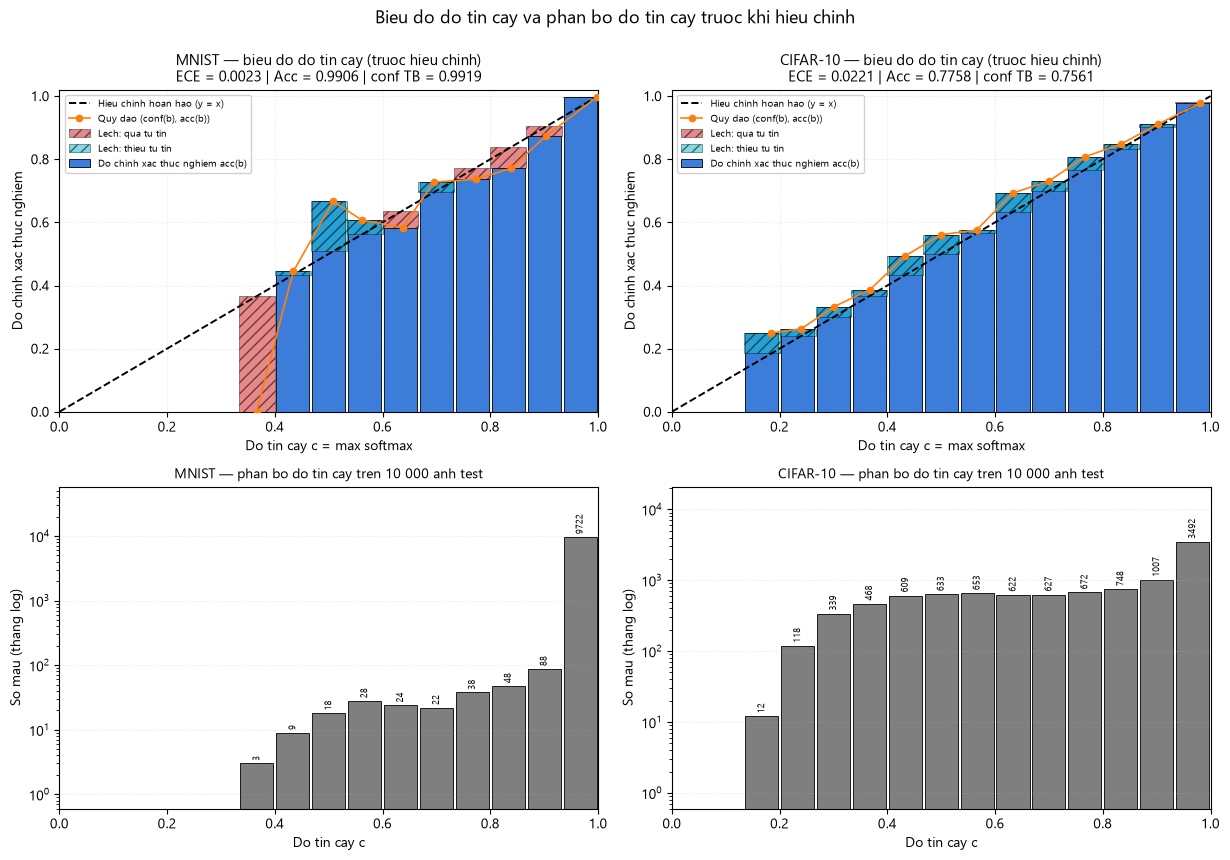

In [10]:
ORDER = [k for k in ("mnist", "cifar10") if k in BUNDLES]


def draw_reliability(ax, stat, title, n_bins=N_BINS):
    """Ve bieu do do tin cay: cot = acc(b), vung gach cheo = khoang lech acc-conf."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    w = 1.0 / n_bins
    acc = np.array(stat["bin_acc"])
    conf = np.array(stat["bin_conf"])
    cnt = np.array(stat["bin_count"])
    nz = cnt > 0

    ax.bar(centers[nz], acc[nz], width=w * 0.92, color="#3b7dd8", zorder=2,
           edgecolor="black", linewidth=0.6, label="Do chinh xac thuc nghiem acc(b)")
    # vung lech ve SAU cot (zorder cao hon) de ca hai chieu lech deu nhin thay duoc:
    # do = qua tu tin (acc < conf), xanh = thieu tu tin (acc > conf)
    for i in np.where(nz)[0]:
        lo, hi = min(acc[i], conf[i]), max(acc[i], conf[i])
        ax.add_patch(Rectangle((edges[i], lo), w, hi - lo, zorder=3,
                               facecolor="#d62728" if acc[i] < conf[i] else "#17becf",
                               alpha=0.55, hatch="///", edgecolor="black", linewidth=0.5))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.4, zorder=4, label="Hieu chinh hoan hao (y = x)")
    ax.plot(conf[nz], acc[nz], "o-", color="#ff7f0e", markersize=4.5, linewidth=1.2, zorder=5,
            label="Quy dao (conf(b), acc(b))")
    ax.add_patch(Rectangle((0, 0), 0, 0, facecolor="#d62728", alpha=0.55, hatch="///",
                           edgecolor="black", linewidth=0.5, label="Lech: qua tu tin"))
    ax.add_patch(Rectangle((0, 0), 0, 0, facecolor="#17becf", alpha=0.55, hatch="///",
                           edgecolor="black", linewidth=0.5, label="Lech: thieu tu tin"))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("Do tin cay c = max softmax")
    ax.set_ylabel("Do chinh xac thuc nghiem")
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3, linestyle=":")
    ax.legend(loc="upper left", fontsize=7.5, framealpha=0.9)


fig, axes = plt.subplots(2, len(ORDER), figsize=(6.2 * len(ORDER), 8.6), squeeze=False)
for j, key in enumerate(ORDER):
    bd, st = BUNDLES[key], CALIB[key]["before"]
    draw_reliability(
        axes[0][j], st,
        f"{bd['name']} — bieu do do tin cay (truoc hieu chinh)\n"
        f"ECE = {st['ece']:.4f} | Acc = {st['accuracy']:.4f} | conf TB = {st['mean_conf']:.4f}")

    ax = axes[1][j]
    edges = np.linspace(0, 1, N_BINS + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    cnt = np.array(st["bin_count"])
    ax.bar(centers, np.maximum(cnt, 0.6), width=(1 / N_BINS) * 0.92,
           color="#7f7f7f", edgecolor="black", linewidth=0.6)
    for i in np.where(cnt > 0)[0]:
        ax.text(centers[i], cnt[i] * 1.18, f"{cnt[i]}", ha="center", fontsize=6.5, rotation=90)
    ax.set_yscale("log"); ax.set_xlim(0, 1); ax.set_ylim(0.6, cnt.max() * 6)
    ax.set_xlabel("Do tin cay c"); ax.set_ylabel("So mau (thang log)")
    ax.set_title(f"{bd['name']} — phan bo do tin cay tren 10 000 anh test", fontsize=10)
    ax.grid(alpha=0.3, linestyle=":", axis="y")

fig.suptitle("Bieu do do tin cay va phan bo do tin cay truoc khi hieu chinh",
             fontsize=13, y=0.995)
fig.tight_layout()
save_fig(fig, "fig_reliability_diagram.png")
plt.show()

### Diễn giải Hình `fig_reliability_diagram.png`

Hàng trên là biểu đồ độ tin cậy, hàng dưới là phân bố độ tin cậy trên thang log. Hai hàng phải
được đọc cùng nhau, vì đọc riêng hàng trên sẽ dẫn tới kết luận sai, và mức độ sai lệch khác hẳn
nhau giữa hai miền.

**MNIST.** Mắt lập tức bị hút vào các cột ở giữa nằm lệch khỏi đường chéo, đặc biệt cột tại
khoảng $[0{,}3333;\,0{,}4000)$ tụt hẳn xuống 0,0000. Ấn tượng thị giác là mô hình lệch hiệu chỉnh
rất nặng. Hàng dưới sửa lại ngay: cột đó chỉ chứa **3 ảnh**, còn cột cuối cùng chứa 9 722 ảnh.
Ước lượng độ chính xác trên ba mẫu không mang thông tin gì; ba ảnh cùng sai là chuyện hoàn toàn
bình thường. Trục log là bắt buộc ở đây, vì trên trục tuyến tính toàn bộ chín cột đầu sẽ dí sát
đáy và không đọc được. Đây chính là lý do ECE dùng **trọng số theo số mẫu** $|S_b|/N$ chứ không
lấy trung bình đơn giản: nếu lấy trung bình không trọng số trên mười khoảng có dữ liệu của MNIST,
độ lệch trung bình sẽ là 0,0800, tức lớn hơn ba mươi lăm lần ECE thực tế 0,002277, và con số đó
sẽ cho một khoảng 3 ảnh cùng tiếng nói với một khoảng 9 722 ảnh.

**CIFAR-10.** Hình của CIFAR-10 đọc được theo nghĩa đen hơn nhiều, và đó tự nó là một quan sát
đáng giá. Phân bố độ tin cậy trải khá đều trên 13 khoảng, mỗi khoảng ở giữa chứa từ 600 đến 750
ảnh, nên ước lượng $\mathrm{acc}(b)$ ở đây **đủ mẫu để tin được**. Và thứ ta thấy là một xu hướng
có hệ thống chứ không phải nhiễu: gần như toàn bộ cột nằm **trên** đường chéo, tương ứng với vùng
gạch chéo màu xanh lam (thiếu tự tin) chiếm ưu thế áp đảo so với màu đỏ. Quỹ đạo màu cam nằm trên
đường chéo suốt từ độ tin cậy 0,18 đến 0,90, rồi mới cắt xuống dưới ở khoảng cuối cùng.

Sự tương phản giữa hai hình vì thế tóm gọn toàn bộ mục này: **với MNIST, sự xen kẽ đỏ và xanh ở
vùng giữa là nhiễu lấy mẫu trên vài chục ảnh; với CIFAR-10, màu xanh chiếm ưu thế trên hàng nghìn
ảnh là một tín hiệu thật.** Chỉ ở khoảng cuối của MNIST, nơi có đủ 9 722 mẫu, ta mới đọc được một
độ lệch đáng tin, và độ lệch đó âm, tức mô hình MNIST quá tự tin.

MNIST: cuc tieu tren luoi tai T = 1.1513 (NLL = 0.033699); L-BFGS cho T = 1.150090 (NLL = 0.033699)
CIFAR-10: cuc tieu tren luoi tai T = 0.9412 (NLL = 0.646777); L-BFGS cho T = 0.940456 (NLL = 0.646776)


Da luu hinh: ..\reports\figures\fig_temperature_scaling.png  (230 KB)


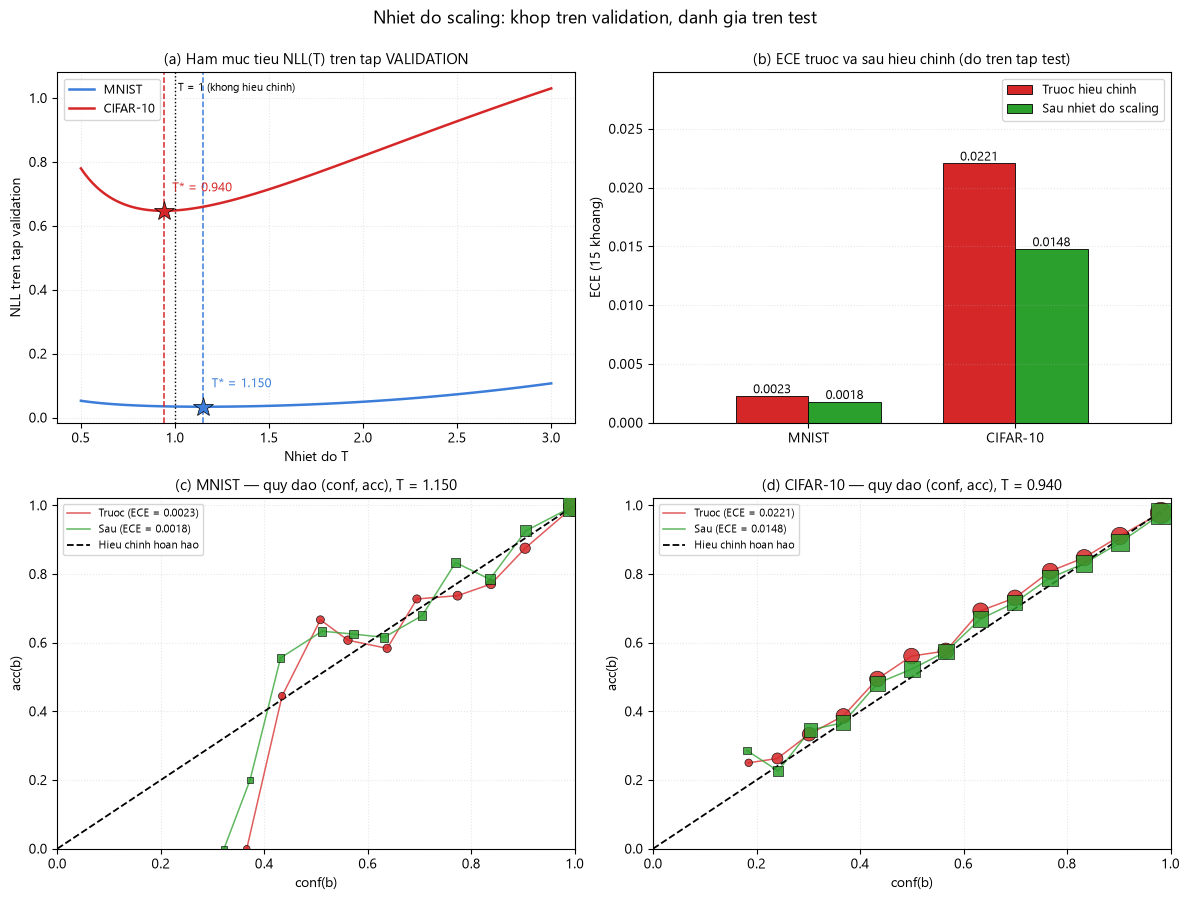

In [11]:
# ----- duong cong NLL theo T tren tap validation, de thay cuc tieu nam o dau -----
T_GRID = np.linspace(0.5, 3.0, 120)
NLL_CURVE = {}
for key, bd in BUNDLES.items():
    lv = LOGITS[key]["val"].to(DEVICE)
    yv = torch.from_numpy(bd["y_val"]).to(DEVICE)
    with torch.no_grad():
        NLL_CURVE[key] = np.array(
            [float(F.cross_entropy(lv / float(t), yv).item()) for t in T_GRID])
    i = int(NLL_CURVE[key].argmin())
    print(f"{bd['name']}: cuc tieu tren luoi tai T = {T_GRID[i]:.4f} "
          f"(NLL = {NLL_CURVE[key][i]:.6f}); L-BFGS cho T = {CALIB[key]['T']:.6f} "
          f"(NLL = {CALIB[key]['nll_val_after']:.6f})")

ncol = max(2, len(ORDER))
fig, axes = plt.subplots(2, ncol, figsize=(6.0 * ncol, 9.0), squeeze=False)

# (a) duong cong NLL(T) tren validation
ax = axes[0][0]
colors = {"mnist": "#3b7dd8", "cifar10": "#d62728"}
for key in ORDER:
    bd = BUNDLES[key]
    ax.plot(T_GRID, NLL_CURVE[key], color=colors[key], linewidth=1.8, label=bd["name"])
    T = CALIB[key]["T"]
    ax.axvline(T, color=colors[key], linestyle="--", linewidth=1.1)
    ax.plot([T], [CALIB[key]["nll_val_after"]], "*", color=colors[key], markersize=15,
            markeredgecolor="black", markeredgewidth=0.5)
    ax.annotate(f"T* = {T:.3f}", xy=(T, CALIB[key]["nll_val_after"]),
                xytext=(6, 14), textcoords="offset points", fontsize=9, color=colors[key])
ax.axvline(1.0, color="black", linestyle=":", linewidth=1.0)
ax.text(1.0, ax.get_ylim()[1] * 0.97, " T = 1 (khong hieu chinh)", fontsize=8, va="top")
ax.set_xlabel("Nhiet do T"); ax.set_ylabel("NLL tren tap validation")
ax.set_title("(a) Ham muc tieu NLL(T) tren tap VALIDATION", fontsize=11)
ax.grid(alpha=0.3, linestyle=":"); ax.legend(fontsize=9)

# (b) ECE truoc / sau
ax = axes[0][1]
x = np.arange(len(ORDER)); w = 0.35
e0 = [CALIB[k]["before"]["ece"] for k in ORDER]
e1 = [CALIB[k]["after"]["ece"] for k in ORDER]
b0 = ax.bar(x - w / 2, e0, w, label="Truoc hieu chinh", color="#d62728", edgecolor="black", linewidth=0.6)
b1 = ax.bar(x + w / 2, e1, w, label="Sau nhiet do scaling", color="#2ca02c", edgecolor="black", linewidth=0.6)
for rect, v in list(zip(b0, e0)) + list(zip(b1, e1)):
    ax.text(rect.get_x() + rect.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([BUNDLES[k]["name"] for k in ORDER])
ax.set_xlim(-0.75, len(ORDER) - 1 + 0.75)
ax.set_ylabel("ECE (15 khoang)")
ax.set_title("(b) ECE truoc va sau hieu chinh (do tren tap test)", fontsize=11)
ax.grid(alpha=0.3, linestyle=":", axis="y"); ax.legend(fontsize=9)
ax.set_ylim(0, max(e0 + e1) * 1.35)

# (c...) quy dao (conf, acc) truoc vs sau, moi mien mot panel.
# Kich thuoc dau danh ti le voi CAN BAC HAI so mau trong khoang, de khoang chi
# chua vai anh khong bi doc ngang hang voi khoang chua chin nghin anh.
for j, key in enumerate(ORDER):
    ax = axes[1][j]
    bd = BUNDLES[key]
    for stat, lab, col, mk in ((CALIB[key]["before"], "Truoc", "#d62728", "o"),
                               (CALIB[key]["after"], "Sau", "#2ca02c", "s")):
        cnt = np.array(stat["bin_count"]); nz = cnt > 0
        xs_ = np.array(stat["bin_conf"])[nz]; ys_ = np.array(stat["bin_acc"])[nz]
        ax.plot(xs_, ys_, "-", color=col, linewidth=1.1, alpha=0.75,
                label=f"{lab} (ECE = {stat['ece']:.4f})")
        ax.scatter(xs_, ys_, s=np.clip(14 + 4.5 * np.sqrt(cnt[nz]), 14, 230), marker=mk,
                   color=col, edgecolor="black", linewidth=0.5, alpha=0.85, zorder=3)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.3, label="Hieu chinh hoan hao")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("conf(b)"); ax.set_ylabel("acc(b)")
    ax.set_title(f"({chr(99 + j)}) {bd['name']} — quy dao (conf, acc), T = {CALIB[key]['T']:.3f}",
                 fontsize=11)
    ax.grid(alpha=0.3, linestyle=":"); ax.legend(loc="upper left", fontsize=8)

for j in range(len(ORDER), ncol):
    axes[1][j].axis("off")

fig.suptitle("Nhiet do scaling: khop tren validation, danh gia tren test", fontsize=13, y=0.995)
fig.tight_layout()
save_fig(fig, "fig_temperature_scaling.png")
plt.show()

### Diễn giải Hình `fig_temperature_scaling.png`

**Panel (a): hàm mục tiêu.** Cả hai đường NLL theo $T$ đều lồi và có đúng một cực tiểu, nhưng
chúng nằm ở hai phía của mốc $T = 1$. MNIST đạt cực tiểu tại $T^{\star} = 1{,}1501$, CIFAR-10 tại
$T^{\star} = 0{,}9405$. Quét lưới 120 giá trị cho cực tiểu tại 1,1513 và 0,9412, khớp với nghiệm
L-BFGS tới ba chữ số thập phân, xác nhận thuật toán hội tụ đúng chứ không dừng ở một điểm bất kỳ.
Đọc trực tiếp từ hình: **mạng MNIST cần bị làm tù đi, mạng CIFAR-10 cần được làm nhọn thêm.**
NLL trên validation giảm từ 0,034323 xuống 0,033699 với MNIST và từ 0,648007 xuống 0,646776 với
CIFAR-10, tức cải thiện lần lượt 1,8% và 0,2% tương đối. Cả hai đều rất khiêm tốn, vì đường cong
rất phẳng quanh cực tiểu.

Về mặt phương pháp, cần nói rõ và nói một lần: **$T$ được khớp trên tập validation và chỉ trên tập
validation**, 12 000 ảnh với MNIST và 10 000 ảnh với CIFAR-10. Tập test 10 000 ảnh của mỗi miền
chỉ dùng để *báo cáo* ECE trước và sau. Nếu khớp $T$ trên chính tập test rồi báo cáo ECE cũng trên
tập test thì đó là rò rỉ dữ liệu, con số sẽ đẹp một cách giả tạo và toàn bộ mục này mất giá trị.

**Panel (b): ECE trước và sau.** MNIST giảm từ 0,002277 xuống 0,001783 (giảm 21,7% tương đối);
CIFAR-10 giảm từ 0,022067 xuống 0,014780 (giảm 33,0% tương đối). Về tuyệt đối, mức cải thiện của
CIFAR-10 là 0,73 điểm phần trăm, lớn gấp gần mười lăm lần mức 0,05 điểm phần trăm của MNIST. Điều
này hợp lý: mô hình nào lệch hiệu chỉnh nhiều hơn thì một tham số duy nhất cũng sửa được nhiều
hơn. Accuracy giữ nguyên đúng bằng 0,9906 và 0,7758 sau hiệu chỉnh, đúng như lập luận ở Mục 2.2,
vì chia mọi logit cho cùng một số dương không đổi thứ tự nên $\arg\max$ không đổi. Đây là phép
kiểm tra tính đúng đắn của cài đặt chứ không phải một kết quả thực nghiệm.

**Panel (c) và (d): quỹ đạo trước so với sau.** Kích thước mỗi dấu tỉ lệ với căn bậc hai số mẫu
trong khoảng, nên dấu bé xíu là những khoảng chỉ có vài ảnh và không nên đọc như bằng chứng.

Với **MNIST**, khoảng cuối được sửa gần như hoàn hảo, còn các khoảng giữa bị đẩy sang trạng thái
thiếu tự tin. Lý do rất cụ thể: **$T$ được chọn để cực tiểu hóa NLL chứ không phải ECE**, và NLL
bị chi phối bởi 97,2% số mẫu nằm ở khoảng cuối. Một vô hướng duy nhất không thể vừa sửa khoảng
cuối vừa giữ nguyên các khoảng giữa, nên nó hy sinh phần thưa để chỉnh phần dày. Nói cách khác,
nhiệt độ scaling **không làm mô hình hiệu chỉnh tốt hơn ở mọi mức tin cậy**; nó dịch chuyển sai số
từ vùng tin cậy cao sang vùng tin cậy trung bình, và tổng có trọng số thì giảm.

Với **CIFAR-10** thì ngược lại và sạch hơn: vì $T < 1$ làm phân phối nhọn thêm, toàn bộ quỹ đạo bị
kéo sang phải, tức độ tin cậy tăng lên và tiến về phía đường chéo ở đúng những khoảng giữa vốn
đang thiếu tự tin. Ở đây mật độ mẫu trải đều nên hàm mục tiêu NLL và chỉ số ECE đồng thuận với
nhau, và đó là lý do mức giảm ECE tương đối của CIFAR-10 (33,0%) lớn hơn của MNIST (21,7%).

**Một quan sát trung thực về quy mô.** NLL trên tập test gần như không đổi ở cả hai miền: MNIST từ
0,027565 xuống 0,027555, CIFAR-10 từ 0,652900 xuống 0,652266. Nhiệt độ scaling cải thiện **sự
khớp của xác suất**, chứ không cải thiện năng lực dự đoán, và với hai mô hình vốn đã không lệch
quá xa thì lợi ích tuyệt đối là nhỏ. Giá trị của mục này nằm ở chỗ nó biến một nhận định định tính
thành ba con số kiểm chứng được: $T = 1{,}1501$ cho MNIST, $T = 0{,}9405$ cho CIFAR-10, và kết
luận rằng **hai mô hình cùng kiến trúc, cùng quy trình huấn luyện, lại lệch hiệu chỉnh về hai
hướng trái ngược nhau tùy theo độ khó của bài toán.**

---

## 5. Phần B — Bộ lọc học được ở tầng tích chập thứ nhất

Tầng Conv đầu tiên là tầng duy nhất tác động **trực tiếp** lên pixel thô, nên trọng số của nó
đọc được như ảnh. Với MNIST tầng này là `Conv2d(1, 32, kernel_size=3, padding=1, bias=False)`,
tức 32 kernel kích thước $3\times3\times1$; với CIFAR-10 là `Conv2d(3, 32, ...)`, tức 32 kernel
$3\times3\times3$ hiển thị được thành ảnh RGB nhỏ.

**Quy ước hiển thị.** Mỗi kernel được chuẩn hóa **độc lập** với các kernel khác, vì biên độ trọng
số giữa các kernel chênh nhau vài lần và nếu dùng chung một thang thì phần lớn ô sẽ xám đều.
Cụ thể: với MNIST dùng thang màu phân kỳ `RdBu_r` với giới hạn đối xứng $\pm\max|w|$ của riêng
kernel đó, nên màu trắng luôn ứng với trọng số 0, đỏ là dương, xanh là âm. Với CIFAR-10, ba kênh
R, G, B được chuẩn hóa **chung một thang** về đoạn $[0,1]$ trong phạm vi từng kernel, để quan hệ
giữa ba kênh (tức đặc trưng màu) không bị phá vỡ.

**Chỉ số lượng hóa.** Thay vì chỉ mô tả bằng mắt, báo cáo tính **tổng trọng số** của mỗi kernel,
$s_f = \sum_{c,u,v} w_{f,c,u,v}$. Đại lượng này chính là đáp ứng của kernel với một vùng ảnh
**đồng nhất** (thành phần một chiều). Kernel có $s_f \approx 0$ triệt tiêu thành phần đồng nhất
nên chỉ phản ứng với **biến thiên cục bộ**, tức là hành xử như bộ dò cạnh hoặc dò tương phản;
kernel có $|s_f|$ lớn thì hoạt động như bộ dò cường độ hay bộ làm mờ có dấu.

In [12]:
# ----- nam mau 3x3 kinh dien de doi chieu, thay vi chi mo ta bang mat -----
TEMPLATES = {
    "DC (do sang deu)":      np.ones((3, 3)),
    "Canh doc (Sobel-x)":    np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float),
    "Canh ngang (Sobel-y)":  np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float),
    "Tan so cao (ban co)":   np.array([[1, -1, 1], [-1, 1, -1], [1, -1, 1]], dtype=float),
    "Tam-vien (dom)":        np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=float),
}
TEMPLATES = {k: v / np.linalg.norm(v) for k, v in TEMPLATES.items()}
TPL_NAMES = list(TEMPLATES)

FILTERS = {}
for key, bd in BUNDLES.items():
    W = bd["conv1"].weight.detach().cpu().numpy()      # (F, C, 3, 3)
    s = W.sum(axis=(1, 2, 3))                          # thanh phan mot chieu cua tung kernel

    # tuong quan cosine giua cau truc KHONG GIAN cua kernel va tung mau
    spatial = W.sum(axis=1)                            # (F, 3, 3): gop kenh mau
    cos = np.zeros((W.shape[0], len(TPL_NAMES)))
    for i in range(W.shape[0]):
        nrm = np.linalg.norm(spatial[i]) + 1e-12
        for j, nm in enumerate(TPL_NAMES):
            cos[i, j] = float((spatial[i] * TEMPLATES[nm]).sum() / nrm)
    best = np.abs(cos).argmax(axis=1)
    best_cos = np.abs(cos).max(axis=1)

    # doi lap mau: ba tong theo kenh co dau khong giong nhau (chi co nghia voi anh RGB)
    chan_dc = W.sum(axis=(2, 3))                       # (F, C)
    n_opponent = int(((chan_dc.max(1) > 0) & (chan_dc.min(1) < 0)).sum()) if W.shape[1] > 1 else 0

    FILTERS[key] = dict(
        W=W, sums=s, cos=cos, best=best, best_cos=best_cos,
        n_filters=int(W.shape[0]), shape=[int(v) for v in W.shape[1:]],
        abs_mean=float(np.abs(W).mean()), std=float(W.std()),
        wmin=float(W.min()), wmax=float(W.max()),
        n_zero_sum=int((np.abs(s) < 0.15).sum()),
        n_weak_match=int((best_cos < 0.6).sum()),
        mean_best_cos=float(best_cos.mean()), n_opponent=n_opponent,
        tally={nm: int((best == j).sum()) for j, nm in enumerate(TPL_NAMES)})

    f = FILTERS[key]
    print(f"===== {bd['name']}: tang Conv dau tien =====")
    print(f"  tensor trong so   : {tuple(W.shape)}  ->  {f['n_filters']} kernel "
          f"kich thuoc {f['shape'][0]}x{f['shape'][1]}x{f['shape'][2]} (C, H, W)")
    print(f"  |w| trung binh    : {f['abs_mean']:.4f}   do lech chuan: {f['std']:.4f}")
    print(f"  bien do           : [{f['wmin']:.4f}, {f['wmax']:.4f}]")
    print(f"  tong trong so s_f : min {s.min():+.4f}  max {s.max():+.4f}  "
          f"|s| trung binh {np.abs(s).mean():.4f}")
    print(f"  so kernel |s_f| < 0.15 (trung tinh voi vung dong nhat): "
          f"{f['n_zero_sum']}/{f['n_filters']}")
    if W.shape[1] > 1:
        print(f"  so kernel doi lap mau (tong theo kenh khac dau): "
              f"{f['n_opponent']}/{f['n_filters']}")
    print(f"  --- doi chieu voi nam mau 3x3 kinh dien (tuong quan cosine) ---")
    for nm in TPL_NAMES:
        idx = np.where(best == TPL_NAMES.index(nm))[0]
        print(f"    {nm:22s}: {f['tally'][nm]:2d} kernel  {[int(v) for v in idx]}")
    print(f"  |cos| lon nhat trung binh: {f['mean_best_cos']:.4f}"
          f"   (1,0 = trung khop hoan toan mot mau)")
    print(f"  so kernel co |cos| lon nhat < 0,6 (khong khop ro mau nao): "
          f"{f['n_weak_match']}/{f['n_filters']}")
    print()

===== MNIST: tang Conv dau tien =====
  tensor trong so   : (32, 1, 3, 3)  ->  32 kernel kich thuoc 1x3x3 (C, H, W)
  |w| trung binh    : 0.1701   do lech chuan: 0.1986
  bien do           : [-0.4063, 0.3902]
  tong trong so s_f : min -0.7732  max +0.9175  |s| trung binh 0.3241
  so kernel |s_f| < 0.15 (trung tinh voi vung dong nhat): 9/32
  --- doi chieu voi nam mau 3x3 kinh dien (tuong quan cosine) ---
    DC (do sang deu)      :  5 kernel  [0, 4, 13, 20, 31]
    Canh doc (Sobel-x)    :  5 kernel  [2, 10, 11, 14, 19]
    Canh ngang (Sobel-y)  : 11 kernel  [5, 6, 7, 8, 9, 12, 15, 23, 24, 27, 28]
    Tan so cao (ban co)   :  4 kernel  [1, 3, 17, 26]
    Tam-vien (dom)        :  7 kernel  [16, 18, 21, 22, 25, 29, 30]
  |cos| lon nhat trung binh: 0.5249   (1,0 = trung khop hoan toan mot mau)
  so kernel co |cos| lon nhat < 0,6 (khong khop ro mau nao): 23/32

===== CIFAR-10: tang Conv dau tien =====
  tensor trong so   : (32, 3, 3, 3)  ->  32 kernel kich thuoc 3x3x3 (C, H, W)
  |w| trung 

Da luu hinh: ..\reports\figures\fig_conv1_filters.png  (84 KB)


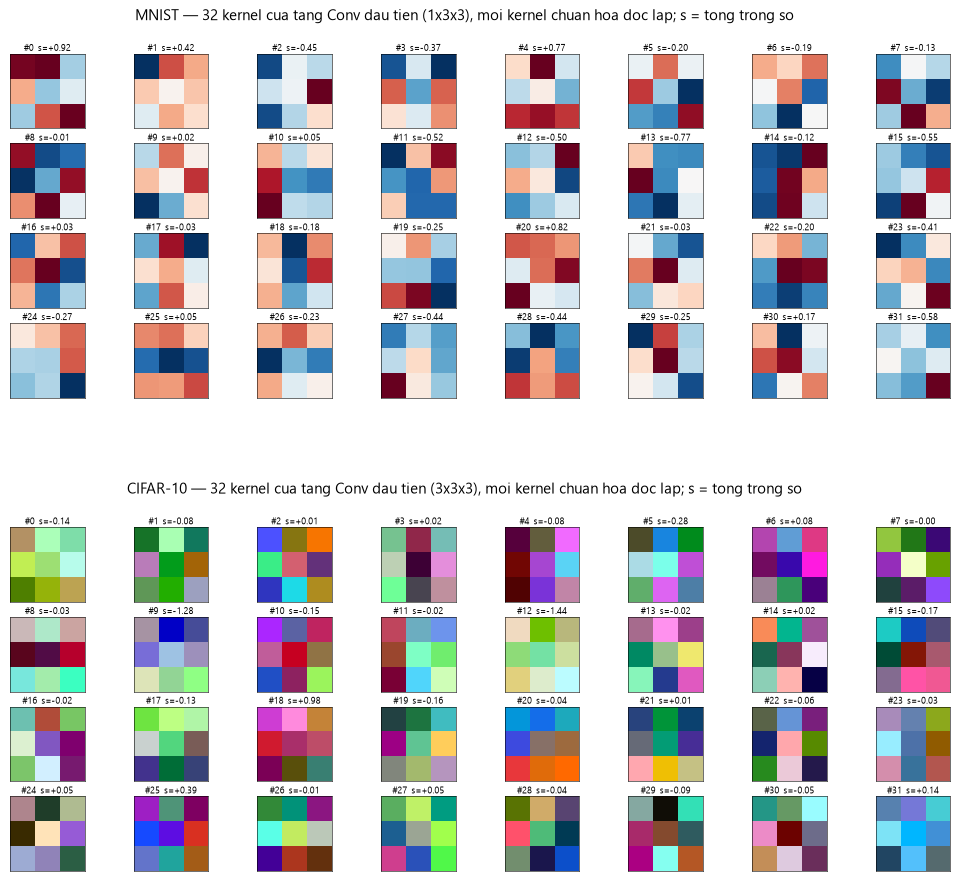

In [13]:
def draw_filter_bank(subfig, bd, finfo, ncols=8):
    W = finfo["W"]
    nrows = int(np.ceil(finfo["n_filters"] / ncols))
    axs = subfig.subplots(nrows, ncols)
    axs = np.atleast_2d(axs)
    for i in range(nrows * ncols):
        ax = axs[i // ncols][i % ncols]
        ax.set_xticks([]); ax.set_yticks([])
        if i >= finfo["n_filters"]:
            ax.axis("off"); continue
        k = W[i]
        if bd["is_rgb"]:
            # chuan hoa CHUNG ba kenh trong pham vi tung kernel -> giu quan he mau
            img = k.transpose(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min() + 1e-12)
            ax.imshow(img, interpolation="nearest")
        else:
            v = float(np.abs(k[0]).max())
            ax.imshow(k[0], cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
        ax.set_title(f"#{i}  s={finfo['sums'][i]:+.2f}", fontsize=6.5, pad=2)
        for sp in ax.spines.values():
            sp.set_linewidth(0.4)
    subfig.suptitle(
        f"{bd['name']} — {finfo['n_filters']} kernel cua tang Conv dau tien "
        f"({finfo['shape'][0]}x{finfo['shape'][1]}x{finfo['shape'][2]}), "
        f"moi kernel chuan hoa doc lap; s = tong trong so",
        fontsize=11)


fig = plt.figure(figsize=(12.5, 4.6 * len(ORDER)))
subfigs = fig.subfigures(len(ORDER), 1, hspace=0.06)
subfigs = np.atleast_1d(subfigs)
for sf, key in zip(subfigs, ORDER):
    draw_filter_bank(sf, BUNDLES[key], FILTERS[key])
save_fig(fig, "fig_conv1_filters.png")
plt.show()

### Diễn giải Hình `fig_conv1_filters.png`

Hai dãy kernel trông khác nhau rõ rệt, và sự khác nhau ấy đo được bằng số chứ không chỉ cảm nhận
bằng mắt.

#### MNIST: bộ dò tương phản có hướng, pha trộn, không phải Gabor

**Điều thực sự nhìn thấy được.** Phần lớn trong 32 kernel có cấu trúc **lưỡng cực**: một phía
dương (đỏ) và phía đối diện âm (xanh), đọc được như bộ dò tương phản theo một hướng, tức xấp xỉ
một đạo hàm không gian. Một nhóm thứ hai có phần lớn ô cùng dấu dương và tổng trọng số lớn, gồm
**#0** ($s = +0{,}92$), **#20** ($+0{,}82$) và **#4** ($+0{,}77$); chúng hành xử như **bộ dò cường
độ**, phát mạnh ở bất kỳ chỗ nào có nét trắng mà không quan tâm hướng. Đối xứng với nhóm đó là
**#13** ($-0{,}77$), **#31** ($-0{,}58$) và **#15** ($-0{,}55$), phát mạnh ở vùng nền tối. Có 9
trên 32 kernel thỏa $|s_f| < 0{,}15$, tiêu biểu là **#8** ($-0{,}01$), **#9** ($+0{,}02$) và
**#16** ($+0{,}03$); chúng triệt tiêu gần hết đáp ứng với một vùng ảnh đồng nhất nên là bộ dò biến
thiên thuần tuý.

**Điều KHÔNG nhìn thấy, và cần nói thẳng.** Không có kernel nào là một bộ lọc Gabor sạch sẽ theo
nghĩa sách giáo khoa, và báo cáo không gán cho chúng một cấu trúc không có thật. Lý do mang tính
hình học chứ không phải do huấn luyện kém: một kernel $3\times3$ chỉ có **chín tham số**, quá ít
để biểu diễn một sóng hình sin có tần số và pha xác định. Cấu trúc Gabor kinh điển mà các bài báo
hay trưng ra thuộc về những mạng có tầng đầu $11\times11$ hoặc $7\times7$ như AlexNet.

#### CIFAR-10: đối lập màu là đặc trưng áp đảo

Dãy CIFAR-10 nhìn bằng mắt đã thấy ngay điểm khác biệt: các kernel **rực rỡ và bão hòa màu**, và
trong cùng một kernel luôn có hai vùng mang hai màu **đối nghịch** nhau. Trục lục và hồng cánh sen
xuất hiện ở **#13**, **#18**, **#29**; trục lam và cam ở **#20**, **#2**, **#23**; trục lục lam và
đỏ ở **#8**, **#14**. Đây chính là hiện tượng **đối lập màu**, tương tự các tế bào đối lập màu
trong thị giác sinh học.

Phép đo xác nhận đúng ấn tượng thị giác đó, và xác nhận rất mạnh: **cả 32 trên 32 kernel đều có
ba tổng theo kênh mang dấu không giống nhau**, nghĩa là không một kernel nào cộng dồn ba kênh màu
cùng chiều. Đồng thời **25 trên 32 kernel có $|s_f| < 0{,}15$** so với chỉ 9 trên 32 ở MNIST, và
$|s_f|$ trung bình chỉ 0,1902 so với 0,3241 của MNIST. Nói cách khác, tầng một của CIFAR-10 gần
như **không học bộ dò độ sáng nào cả**: bảng đối chiếu với năm mẫu kinh điển cho **0 kernel** thuộc
nhóm "độ sáng đều", trong khi MNIST có 5.

Cách giải thích tự nhiên là phân công lao động giữa hai loại thông tin. Với ảnh xám, độ sáng là
tín hiệu duy nhất nên một phần tầng một phải dành ra để đo nó. Với ảnh màu, thông tin đã nằm sẵn
trong tương quan giữa ba kênh, nên tầng một tự do chuyên môn hóa vào **tương phản màu và tương
phản không gian** thay vì mức sáng tuyệt đối.

#### Kiểm chứng bằng số thay vì bằng mắt, và giới hạn của chính phép kiểm đó

Để không dừng ở mô tả cảm tính, báo cáo đối chiếu cấu trúc không gian của từng kernel với năm mẫu
$3\times3$ kinh điển bằng tương quan cosine:

| Mẫu khớp nhất | MNIST | CIFAR-10 |
|---|---|---|
| Độ sáng đều (DC) | 5 | **0** |
| Cạnh dọc (Sobel-x) | 5 | 10 |
| Cạnh ngang (Sobel-y) | 11 | 9 |
| Tần số cao (bàn cờ) | 4 | 5 |
| Tâm-viền (đốm) | 7 | 8 |
| $|\cos|$ lớn nhất trung bình | 0,5249 | **0,5949** |
| Số kernel có $|\cos| < 0{,}6$ | 23 / 32 | 17 / 32 |

Kernel của CIFAR-10 khớp mẫu **rõ hơn** kernel của MNIST: $|\cos|$ trung bình 0,5949 so với
0,5249, và chỉ 17 trên 32 dưới ngưỡng 0,6 so với 23 trên 32. Về cấu trúc không gian, tầng một của
CIFAR-10 ngả hẳn về dò cạnh, với 19 trên 32 kernel rơi vào hai nhóm Sobel.

Nhưng con số quan trọng nhất là con số làm yếu chính bảng phân loại đó: ngay cả với CIFAR-10,
$|\cos|$ trung bình mới chỉ là 0,5949, và hơn một nửa số kernel vẫn dưới ngưỡng 0,6. Nghĩa là
**phần lớn kernel không khớp rõ ràng với bất kỳ mẫu kinh điển nào; chúng là các tổ hợp lai.** Bảng
trên phải đọc như một cách sắp xếp thô để tiện mô tả, chứ không phải một tuyên bố rằng mạng đã học
ra đúng bộ lọc Sobel.

Diễn giải trung thực cuối cùng: **tầng một của cả hai mô hình học được các bộ dò tương phản cục bộ
có hướng, đa dạng và không chuẩn hoá về bất kỳ dạng giáo khoa nào; điểm khác biệt có thể khẳng
định chắc chắn giữa hai miền là CIFAR-10 học đối lập màu ở toàn bộ 32 kernel và gần như từ bỏ
việc đo độ sáng tuyệt đối.** Không có kernel chết ở cả hai miền: biên độ trọng số là
$[-0{,}4063;\,0{,}3902]$ với MNIST và $[-0{,}5640;\,0{,}3370]$ với CIFAR-10, không kernel nào bị
co về 0, và mọi ô đều có cấu trúc dấu mạch lạc chứ không lốm đốm ngẫu nhiên như nhiễu trắng.

---

## 6. Phần C — Bản đồ đặc trưng theo độ sâu

Mục này đẩy **một ảnh test được phân loại đúng** qua từng khối và vẽ các bản đồ đặc trưng thu
được. Mục đích là quan sát hai hiện tượng đồng thời xảy ra khi đi sâu vào mạng:

- **Nén không gian.** Mỗi khối kết thúc bằng `MaxPool2d(2)` nên chiều cao và chiều rộng giảm một
  nửa sau mỗi khối. Kích thước tensor được ghi rõ ở nhãn từng hàng.
- **Trừu tượng hóa.** Ở khối một, bản đồ đặc trưng còn nhìn ra hình dáng gốc vì kernel mới chỉ
  dò cạnh và tương phản. Càng sâu, mỗi ô càng tổng hợp một vùng ảnh rộng hơn (trường tiếp nhận
  lớn dần) nên bản đồ mất dần tính "giống ảnh" và trở thành tập các điểm kích hoạt rời rạc.

**Quy ước chọn kênh.** Mỗi khối có 32 hoặc 64 kênh, quá nhiều để vẽ hết, nên báo cáo chọn 8 kênh
có **giá trị kích hoạt trung bình lớn nhất** trên chính ảnh đó. Chọn theo tiêu chí này thay vì
lấy 8 kênh đầu là có lý do: sau ReLU, một tỉ lệ đáng kể kênh bị tắt hoàn toàn trên một ảnh cụ
thể, và vẽ đúng những kênh chết sẽ chỉ cho ra tám ô đen không mang thông tin gì.

In [14]:
FEATMAP = {}
for key, bd in BUNDLES.items():
    cal = CALIB[key]["before"]
    idx = int(np.where(cal["correct"] == 1)[0][0])          # anh dung dau tien, tat dinh
    x1 = bd["to_tensor"](bd["x_test"][idx:idx + 1]).to(DEVICE)
    acts, h = [], x1
    with torch.no_grad():
        for name, blk in bd["blocks"]:
            h = blk(h)
            acts.append((name, h.cpu().numpy()[0]))         # (C, H, W)
    FEATMAP[key] = dict(idx=idx, x1shape=tuple(x1.shape), acts=acts)

    print(f"===== {bd['name']}: anh test #{idx}, nhan that = "
          f"{bd['classes'][bd['y_test'][idx]]}, du doan = {bd['classes'][cal['pred'][idx]]}, "
          f"do tin cay = {cal['conf'][idx]:.4f} =====")
    print(f"  dau vao        : {tuple(x1.shape)}")
    for name, a in acts:
        print(f"  {name:<14}: (1, {a.shape[0]}, {a.shape[1]}, {a.shape[2]})"
              f"   ti le o bang 0 sau ReLU = {float((a == 0).mean()):.4f}"
              f"   kich hoat lon nhat = {float(a.max()):.3f}")
    print()

===== MNIST: anh test #0, nhan that = 7, du doan = 7, do tin cay = 1.0000 =====
  dau vao        : (1, 1, 28, 28)
  Khoi 1        : (1, 32, 14, 14)   ti le o bang 0 sau ReLU = 0.6191   kich hoat lon nhat = 4.021
  Khoi 2        : (1, 64, 7, 7)   ti le o bang 0 sau ReLU = 0.5258   kich hoat lon nhat = 5.311

===== CIFAR-10: anh test #0, nhan that = mèo, du doan = mèo, do tin cay = 0.6929 =====
  dau vao        : (1, 3, 32, 32)
  Khoi 1        : (1, 32, 16, 16)   ti le o bang 0 sau ReLU = 0.4176   kich hoat lon nhat = 6.457
  Khoi 2        : (1, 64, 8, 8)   ti le o bang 0 sau ReLU = 0.5925   kich hoat lon nhat = 2.101
  Khoi 3        : (1, 64, 4, 4)   ti le o bang 0 sau ReLU = 0.4883   kich hoat lon nhat = 1.823



Da luu hinh: ..\reports\figures\fig_feature_maps.png  (95 KB)


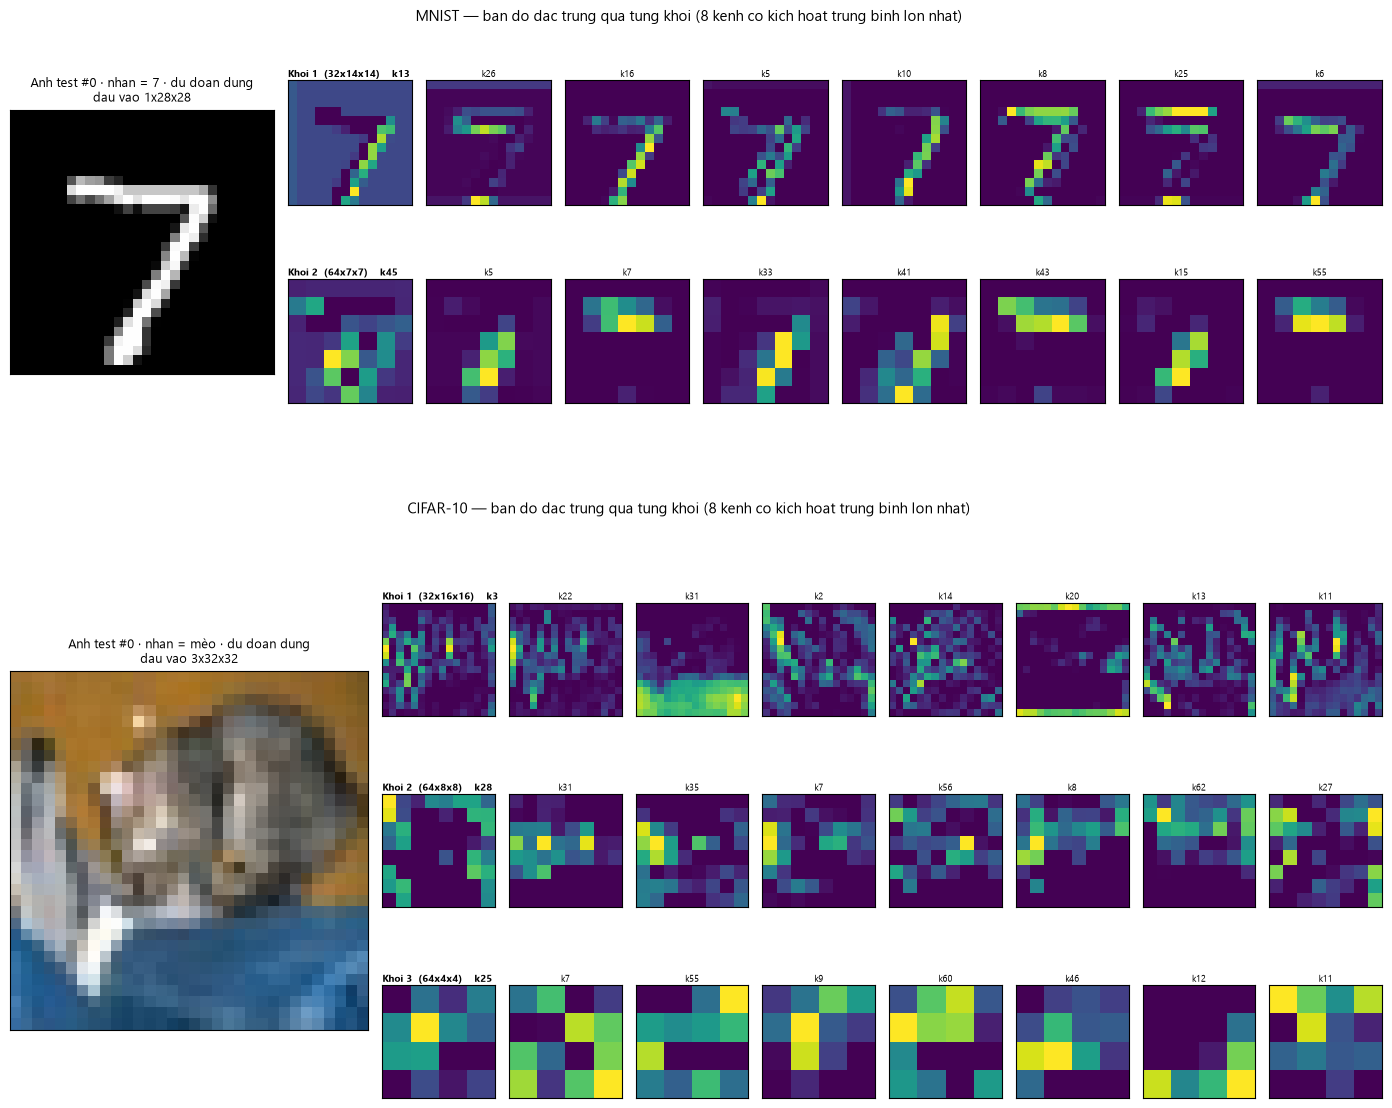

In [15]:
N_SHOW = 8


def draw_feature_maps(subfig, bd, fm):
    acts = fm["acts"]
    nrows = len(acts)
    # cot anh goc rong bang nrows don vi de o ANH VUONG lap day chieu cao nrows hang,
    # neu khong se thua mot mang trang lon o ben trai
    gs = subfig.add_gridspec(nrows, N_SHOW + 1,
                             width_ratios=[nrows * 1.06] + [1] * N_SHOW,
                             wspace=0.10, hspace=0.26, left=0.015, right=0.995,
                             top=0.82, bottom=0.03)
    ax0 = subfig.add_subplot(gs[:, 0])
    img = bd["x_test"][fm["idx"]]
    ax0.imshow(img, cmap=bd["cmap"], interpolation="nearest")
    ax0.set_xticks([]); ax0.set_yticks([])
    ax0.set_title(f"Anh test #{fm['idx']} · nhan = "
                  f"{bd['classes'][bd['y_test'][fm['idx']]]} · du doan dung\n"
                  f"dau vao {fm['x1shape'][1]}x{fm['x1shape'][2]}x{fm['x1shape'][3]}",
                  fontsize=9)

    for r, (name, a) in enumerate(acts):
        order = np.argsort(-a.mean(axis=(1, 2)))[:N_SHOW]     # 8 kenh kich hoat manh nhat
        for c in range(N_SHOW):
            ax = subfig.add_subplot(gs[r, c + 1])
            ch = int(order[c])
            ax.imshow(a[ch], cmap="viridis", interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if c == 0:
                # nhan hang dat thang vao tieu de o dau tien, can trai, de khong bi cat
                ax.set_title(f"{name}  ({a.shape[0]}x{a.shape[1]}x{a.shape[2]})    k{ch}",
                             fontsize=7.5, pad=2.5, loc="left", fontweight="bold")
            else:
                ax.set_title(f"k{ch}", fontsize=6.5, pad=2.5)
    subfig.suptitle(f"{bd['name']} — ban do dac trung qua tung khoi "
                    f"(8 kenh co kich hoat trung binh lon nhat)", fontsize=11, y=0.94)


fig = plt.figure(figsize=(14.0, 2.05 * sum(len(FEATMAP[k]["acts"]) for k in ORDER) + 1.3))
subfigs = fig.subfigures(len(ORDER), 1, hspace=0.05,
                         height_ratios=[len(FEATMAP[k]["acts"]) for k in ORDER])
subfigs = np.atleast_1d(subfigs)
for sf, key in zip(subfigs, ORDER):
    draw_feature_maps(sf, BUNDLES[key], FEATMAP[key])
save_fig(fig, "fig_feature_maps.png")
plt.show()

### Diễn giải Hình `fig_feature_maps.png`

Ảnh được chọn ở mỗi miền là ảnh test đầu tiên được phân loại đúng, tức ảnh số 0 trong cả hai
trường hợp: chữ số 7 với MNIST (độ tin cậy 1,0000) và một con **mèo** với CIFAR-10 (độ tin cậy
0,6929).

#### Nén không gian, đọc được ngay từ nhãn kích thước

| Tầng | MNIST | CIFAR-10 |
|---|---|---|
| Đầu vào | $1\times28\times28$ (784 phần tử) | $3\times32\times32$ (3 072) |
| Khối 1 | $32\times14\times14$ (6 272) | $32\times16\times16$ (8 192) |
| Khối 2 | $64\times7\times7$ (3 136) | $64\times8\times8$ (4 096) |
| Khối 3 | không có | $64\times4\times4$ (1 024) |

Chiều không gian giảm một nửa sau mỗi khối do `MaxPool2d(2)`, trong khi số kênh tăng gấp đôi rồi
giữ nguyên. Tổng số phần tử phình ra ở khối một rồi co lại đều đặn. Mạng không nén thông tin một
cách đơn điệu mà **đổi trục biểu diễn**: bỏ bớt độ phân giải không gian để mua thêm độ phong phú
về loại đặc trưng. Với CIFAR-10, khối ba ép xuống chỉ còn $4\times4$, tức mỗi ô tóm tắt một vùng
$8\times8$ pixel của ảnh gốc.

#### MNIST: khối 1 vẫn còn giống ảnh, khối 2 thì không

Trong tám kênh được vẽ ở Khối 1, chữ số 7 còn nhận ra được ở mọi kênh, và khác biệt giữa các kênh
đúng là thứ mà Phần B dự đoán. Kênh k8 và k25 làm sáng rõ **nét ngang phía trên** của chữ 7 và gần
như bỏ qua nét xiên; ngược lại k13, k16 và k5 làm nổi **nét xiên đi xuống** và để nét ngang mờ đi.
Đây đúng là hành vi của những bộ dò tương phản có hướng khác nhau đã đo ở Phần B: mỗi kernel phản
ứng mạnh với một hướng nét, nên cùng một chữ số bị tách thành các thành phần hướng. Kênh k13 có
nền sáng đều thay vì nền tối, tức một kênh có độ lệch dương lớn ở vùng nền.

Ở Khối 2 với kích thước $7\times7$, mỗi ô tương ứng một vùng khá rộng của ảnh gốc nên hình dáng
chữ số không còn đọc trực tiếp được. Bản đồ trở thành tập các điểm kích hoạt rời rạc: k7, k43 và
k55 giữ lại một dải ngang sáng ở hàng trên, tương ứng nét ngang của chữ 7; k33, k41 và k15 giữ lại
một dải chéo. Biểu diễn đã chuyển từ *"chỗ nào có nét"* sang *"có hay không một bộ phận kiểu này,
ở đâu đó quanh vùng này"*, đúng nghĩa trừu tượng hoá theo độ sâu.

#### CIFAR-10: ngay khối 1 đã KHÔNG còn giống ảnh

Đây là điểm tương phản đáng giá nhất của mục này, và nó đi ngược trực giác thông thường rằng
"tầng đầu luôn giống ảnh gốc". Ở Khối 1 của CIFAR-10, **không kênh nào cho ra một hình con mèo
nhận ra được**. Thứ ta thấy là các vùng màu và kết cấu: kênh k31 sáng rực ở **dải dưới cùng**,
đúng vùng nền xanh lam của ảnh, tức một kênh chọn lọc theo màu chứ không theo hình; k3, k22 và k11
cho ra kết cấu lấm tấm dày đặc tập trung ở nửa trái nơi có vật thể sáng màu; k2 và k14 làm nổi
một đường biên chéo.

Đặc biệt, kênh **k20 chỉ sáng ở đúng hàng trên cùng và hàng dưới cùng** của bản đồ, còn toàn bộ
phần giữa tối đen. Đó không phải một đặc trưng của ảnh mà là **giả tượng của phép đệm viền**: kernel
$3\times3$ với `padding=1` nhìn thấy các số 0 ngoài biên, tạo ra một bậc tương phản nhân tạo mà một
kernel nhạy độ sáng sẽ phản ứng theo. Báo cáo ghi nhận đây là giả tượng chứ không diễn giải nó như
một đặc trưng có ý nghĩa ngữ nghĩa.

Lý do của toàn bộ sự khác biệt này khá rõ: chữ số MNIST là hình nhị phân gần như thuần tuý trên nền
đen, nên một bộ dò cạnh áp lên nó vẫn trả về chính hình đó; còn ảnh tự nhiên $32\times32$ có kết
cấu, nền phức tạp và độ tương phản trải đều, nên đáp ứng của cùng loại bộ dò cạnh là một trường
kết cấu chứ không phải một hình bóng. Sang Khối 2 và Khối 3, bản đồ chỉ còn lần lượt $8\times8$ và
$4\times4$ ô; ở Khối 3 chỉ còn 16 ô mỗi kênh, nên mọi khái niệm "định vị không gian" đã tan biến
và cái còn lại thuần tuý là một mã đặc trưng.

#### Độ thưa theo độ sâu: không đơn điệu, và báo cáo giữ nguyên số đo

Tỉ lệ phần tử bằng 0 sau ReLU là 0,6191 rồi 0,5258 với MNIST, và 0,4176 rồi 0,5925 rồi 0,4883 với
CIFAR-10. Kỳ vọng thông thường là độ thưa **tăng** dần theo độ sâu; số đo cho thấy nó dao động
chứ không đơn điệu ở cả hai miền.

Giải thích nằm ở `MaxPool2d`: phép lấy cực đại trên cửa sổ $2\times2$ chỉ cho ra 0 khi **cả bốn**
giá trị trong cửa sổ đều bằng 0, nên nó **giảm** độ thưa một cách có hệ thống, ngược chiều với
ReLU vốn làm tăng độ thưa. Tỉ lệ quan sát được là kết quả của hai lực ngược chiều nhau chứ không
của riêng ReLU. Với MNIST, nơi phần lớn diện tích ảnh là nền đen, hiệu ứng làm giảm độ thưa của
MaxPool ở Khối 1 rất mạnh. Kích hoạt lớn nhất cũng không đơn điệu: 4,021 rồi 5,311 với MNIST,
nhưng 6,457 rồi 2,101 rồi 1,823 với CIFAR-10, tức biên độ kích hoạt của CIFAR-10 **giảm dần** theo
độ sâu, phù hợp với việc `BatchNorm` chuẩn hóa lại thang đo ở mỗi khối.

---

## 7. Phần D — Độ nhạy che khuất

Ba mục trên nhìn vào **trọng số** và **kích hoạt**. Mục này hỏi một câu khác hẳn, và là câu quan
trọng nhất về mặt tin cậy: **mô hình thực sự dựa vào vùng ảnh nào để ra quyết định?**

Phương pháp (Zeiler và Fergus, 2014) rất trực tiếp: trượt một ô vuông **xám** kích thước
$8\times8$ với bước nhảy 4 trên ảnh, và tại mỗi vị trí ghi lại xác suất mà mô hình gán cho
**lớp đúng**. Gọi $p_{r,c}$ là xác suất khi ô che đặt tại góc $(r,c)$ và $p_0$ là xác suất khi
không che. Khi đó:

- $p_{r,c} \ll p_0$ nghĩa là che vùng đó **phá hủy** quyết định, tức vùng đó thực sự chi phối.
- $p_{r,c} \approx p_0$ nghĩa là vùng đó **không quan trọng**.
- $p_{r,c} > p_0$ nghĩa là che vùng đó **giúp** mô hình, tức vùng đó đang chứa thông tin gây
  nhiễu đẩy mô hình sang lớp khác.

Bản đồ nhiệt của $p_{r,c}$ vì thế phân biệt được hai tình huống rất khác nhau: mô hình **nhìn vào
vật thể** (vùng tối nằm trên vật thể), hay mô hình **bám vào nền** (vùng tối nằm ở nền, dấu hiệu
của một lối tắt thống kê).

**Giá trị của ô che.** Ô che mang giá trị 0,5 trên thang $[0,1]$ và được áp **trước** khi chuẩn
hóa, đúng thứ tự mà một ảnh thật đi qua pipeline. Với MNIST, nền là 0 còn nét là gần 1, nên ô xám
0,5 là một vùng nằm ngoài phân phối huấn luyện; điều này được ghi nhận khi diễn giải kết quả.

**Cách chọn ảnh.** Thay vì lấy vài ảnh tùy ý, báo cáo dùng một quy tắc $2\times2$ tất định trên
hai trục **đúng/sai** và **tự tin/do dự**, chọn ra bốn ảnh: (1) đúng và tin cậy cao nhất,
(2) đúng nhưng tin cậy thấp nhất, (3) sai nhưng tin cậy cao nhất, (4) sai và tin cậy thấp nhất.
Bốn ô này bao trọn các chế độ hành xử của mô hình, và trường hợp (3) chính là hiện tượng "sai với
độ tin cậy cao" mà Chương 6 và Chương 7 đã mô tả nhưng chưa giải thích được là do đâu.

In [16]:
PATCH, STRIDE, GREY = 8, 4, 0.5


@torch.no_grad()
def occlusion_map(bd, img01, y_true, patch=PATCH, stride=STRIDE, grey=GREY):
    """Truot o che va ghi xac suat lop dung tai moi vi tri.

    Tra ve (grid, rows, cols, p0): grid[i, j] la xac suat lop dung khi o che dat
    tai goc tren-trai (rows[i], cols[j]); p0 la xac suat khi khong che.
    """
    H, W = img01.shape[0], img01.shape[1]
    rows = list(range(0, H - patch + 1, stride))
    cols = list(range(0, W - patch + 1, stride))
    batch = np.empty((len(rows) * len(cols),) + img01.shape, dtype=np.float32)
    k = 0
    for r in rows:
        for c in cols:
            o = img01.copy()
            o[r:r + patch, c:c + patch] = grey       # ap TRUOC khi chuan hoa
            batch[k] = o
            k += 1
    p = torch.softmax(bd["model"](bd["to_tensor"](batch).to(DEVICE)), 1)[:, y_true]
    grid = p.cpu().numpy().reshape(len(rows), len(cols))
    p0 = float(torch.softmax(
        bd["model"](bd["to_tensor"](img01[None]).to(DEVICE)), 1)[0, y_true])
    return grid, rows, cols, p0


def pick_2x2(cal):
    """Quy tac tat dinh: (dung, tu tin nhat), (dung, do du nhat), (sai, tu tin nhat), (sai, do du nhat)."""
    conf, corr = cal["conf"], cal["correct"]
    ok, bad = np.where(corr == 1)[0], np.where(corr == 0)[0]
    return [(int(ok[np.argmax(conf[ok])]), "Dung, tin cay cao nhat"),
            (int(ok[np.argmin(conf[ok])]), "Dung, tin cay thap nhat"),
            (int(bad[np.argmax(conf[bad])]), "SAI, tin cay cao nhat"),
            (int(bad[np.argmin(conf[bad])]), "SAI, tin cay thap nhat")]


OCCL = {}
for key, bd in BUNDLES.items():
    cal = CALIB[key]["before"]
    picks = pick_2x2(cal)
    items = []
    torch.cuda.synchronize(); t0 = time.time()
    for idx, tag in picks:
        img = bd["x_test"][idx]
        yt = int(bd["y_test"][idx])
        grid, rows, cols, p0 = occlusion_map(bd, img, yt)
        items.append(dict(index=idx, tag=tag, y_true=yt, y_pred=int(cal["pred"][idx]),
                          conf=float(cal["conf"][idx]), grid=grid, rows=rows, cols=cols,
                          p0=p0, pmin=float(grid.min()), pmax=float(grid.max()),
                          argmin=[int(v) for v in np.unravel_index(grid.argmin(), grid.shape)],
                          argmax=[int(v) for v in np.unravel_index(grid.argmax(), grid.shape)]))
    torch.cuda.synchronize()
    OCCL[key] = items
    n_pos = len(items[0]["rows"]) * len(items[0]["cols"])
    print(f"===== {bd['name']}: {n_pos} vi tri che moi anh "
          f"({len(items[0]['rows'])}x{len(items[0]['cols'])} luoi, o {PATCH}x{PATCH}, "
          f"buoc {STRIDE}), {time.time() - t0:.2f}s cho {len(items)} anh =====")
    for it in items:
        r0 = it["rows"][it["argmin"][0]]; c0 = it["cols"][it["argmin"][1]]
        r1 = it["rows"][it["argmax"][0]]; c1 = it["cols"][it["argmax"][1]]
        print(f"  #{it['index']:<5} [{it['tag']:<24}] that={bd['classes'][it['y_true']]:<10} "
              f"doan={bd['classes'][it['y_pred']]:<10} p0={it['p0']:.6f}  "
              f"p_min={it['pmin']:.6f}@({r0},{c0})  p_max={it['pmax']:.6f}@({r1},{c1})  "
              f"sut_giam_max={it['p0'] - it['pmin']:.6f}")
    print()

===== MNIST: 36 vi tri che moi anh (6x6 luoi, o 8x8, buoc 4), 0.03s cho 4 anh =====
  #1     [Dung, tin cay cao nhat  ] that=2          doan=2          p0=1.000000  p_min=0.999890@(8,8)  p_max=1.000000@(16,0)  sut_giam_max=0.000110
  #8094  [Dung, tin cay thap nhat ] that=2          doan=2          p0=0.406339  p_min=0.011507@(4,20)  p_max=0.829053@(16,20)  sut_giam_max=0.394832
  #9729  [SAI, tin cay cao nhat   ] that=5          doan=6          p0=0.001375  p_min=0.000180@(0,20)  p_max=0.693569@(8,8)  sut_giam_max=0.001195
  #1039  [SAI, tin cay thap nhat  ] that=7          doan=3          p0=0.127158  p_min=0.003806@(12,8)  p_max=0.669525@(8,0)  sut_giam_max=0.123352

===== CIFAR-10: 49 vi tri che moi anh (7x7 luoi, o 8x8, buoc 4), 0.02s cho 4 anh =====
  #1729  [Dung, tin cay cao nhat  ] that=tàu thủy   doan=tàu thủy   p0=0.999999  p_min=0.997373@(16,16)  p_max=0.999999@(0,24)  sut_giam_max=0.002626
  #1813  [Dung, tin cay thap nhat ] that=mèo        doan=mèo        p0=0.182912  p_m

Da luu hinh: ..\reports\figures\fig_occlusion_sensitivity.png  (490 KB)


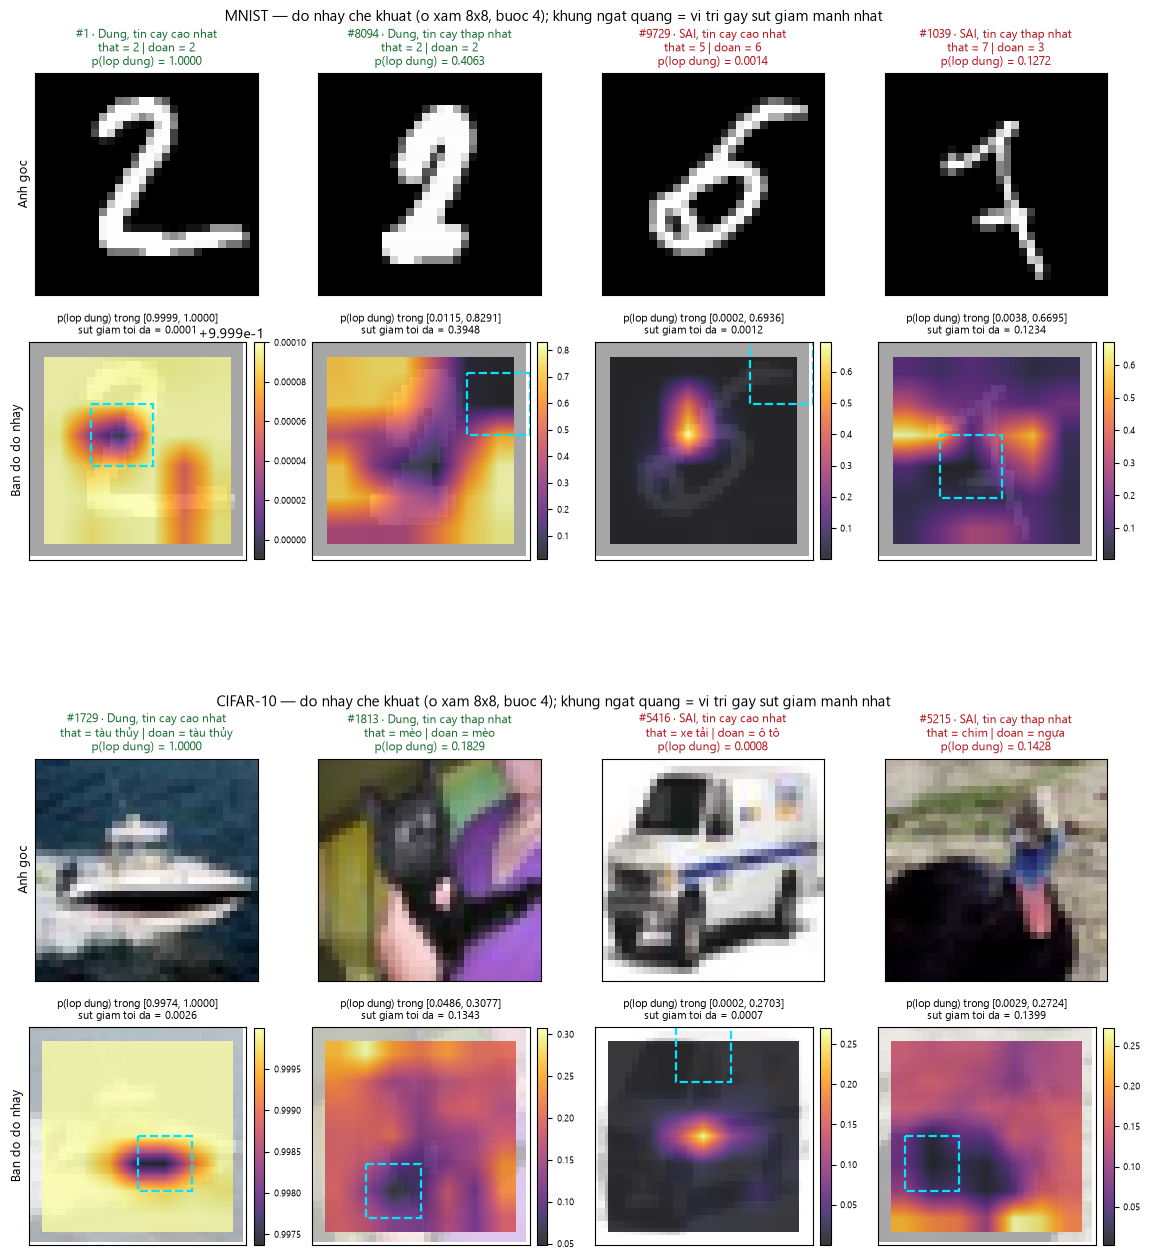

In [17]:
def draw_occlusion(subfig, bd, items):
    n = len(items)
    axs = subfig.subplots(2, n)
    axs = np.atleast_2d(axs)
    for j, it in enumerate(items):
        img = bd["x_test"][it["index"]]
        H, W = img.shape[0], img.shape[1]

        ax = axs[0][j]
        ax.imshow(img, cmap=bd["cmap"], interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        ok = it["y_true"] == it["y_pred"]
        ax.set_title(f"#{it['index']} · {it['tag']}\nthat = {bd['classes'][it['y_true']]}"
                     f" | doan = {bd['classes'][it['y_pred']]}\n"
                     f"p(lop dung) = {it['p0']:.4f}",
                     fontsize=8.5, color="#146c2e" if ok else "#b3121a")

        ax = axs[1][j]
        ax.imshow(img, cmap=bd["cmap"], interpolation="nearest", alpha=0.35)
        ext = (it["cols"][0] + PATCH / 2 - STRIDE / 2, it["cols"][-1] + PATCH / 2 + STRIDE / 2,
               it["rows"][-1] + PATCH / 2 + STRIDE / 2, it["rows"][0] + PATCH / 2 - STRIDE / 2)
        im = ax.imshow(it["grid"], cmap="inferno", extent=ext, alpha=0.78,
                       interpolation="bilinear", vmin=it["pmin"], vmax=it["pmax"])
        # danh dau o che gay sut giam manh nhat
        r0 = it["rows"][it["argmin"][0]]; c0 = it["cols"][it["argmin"][1]]
        ax.add_patch(Rectangle((c0, r0), PATCH, PATCH, fill=False,
                               edgecolor="#00e5ff", linewidth=1.6, linestyle="--"))
        ax.set_xlim(0, W); ax.set_ylim(H, 0)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"p(lop dung) trong [{it['pmin']:.4f}, {it['pmax']:.4f}]\n"
                     f"sut giam toi da = {it['p0'] - it['pmin']:.4f}", fontsize=8)
        cb = subfig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.ax.tick_params(labelsize=6.5)
    axs[0][0].set_ylabel("Anh goc", fontsize=9)
    axs[1][0].set_ylabel("Ban do do nhay", fontsize=9)
    subfig.suptitle(f"{bd['name']} — do nhay che khuat (o xam {PATCH}x{PATCH}, buoc {STRIDE}); "
                    f"khung ngat quang = vi tri gay sut giam manh nhat", fontsize=11)


fig = plt.figure(figsize=(14.0, 6.6 * len(ORDER)))
subfigs = fig.subfigures(len(ORDER), 1, hspace=0.08)
subfigs = np.atleast_1d(subfigs)
for sf, key in zip(subfigs, ORDER):
    draw_occlusion(sf, BUNDLES[key], OCCL[key])
save_fig(fig, "fig_occlusion_sensitivity.png")
plt.show()

### Diễn giải Hình `fig_occlusion_sensitivity.png`

Lưới che là $6\times6 = 36$ vị trí trên ảnh MNIST $28\times28$ và $7\times7 = 49$ vị trí trên ảnh
CIFAR-10 $32\times32$. Thang màu được chuẩn hóa **riêng cho từng ảnh**, vì biên độ thay đổi giữa
các ảnh chênh nhau hơn ba bậc độ lớn; khoảng giá trị thật luôn được ghi trong tiêu đề mỗi panel.
Khung nét đứt màu lam đánh dấu vị trí ô che gây sụt giảm mạnh nhất.

#### MNIST

**Ảnh #1, chữ số 2, đúng và tin cậy 1,0000.** Xác suất lớp đúng dao động trong
$[0{,}999890;\,1{,}000000]$, tức **sụt giảm tối đa chỉ 0,000110**. Không một ô che $8\times8$ nào
làm mô hình lung lay. Điểm tối nhất nằm trên khúc cong phía trên bên trái của chữ 2, là vị trí có
ý nghĩa, nhưng hiệu ứng nhỏ tới mức chỉ đọc được nhờ thang màu co lại tới cỡ $10^{-4}$. Kết luận
trung thực: **thông tin nhận dạng bị dư thừa mạnh**, chữ số được nhận ra từ nhiều vùng độc lập nên
phá một vùng không đủ để phá quyết định.

**Ảnh #8094, chữ số 2, đúng nhưng tin cậy thấp nhất 0,4063.** Xác suất đi từ 0,4063 xuống 0,0115
khi ô che đặt tại góc $(4,20)$, tức **sụt giảm 0,3948** và làm mất hoàn toàn dự đoán đúng. Ngược
lại, xác suất **tăng** lên 0,8291 khi che tại $(16,20)$. Bản đồ nhiệt tối ở vùng nét chữ và sáng ở
vùng rìa chính là dấu hiệu của một mô hình bám vào vật thể.

**Ảnh #9729, chữ số 5 bị đoán thành 6 với độ tin cậy cao.** Đây là hiện tượng "sai với độ tin cậy
cao" mà Chương 6 mô tả, và phép che khuất cho một câu trả lời rất sắc. $p(\text{lớp }5)$ ban đầu
chỉ 0,001375, nhưng **tăng vọt lên 0,693569 khi che tại $(8,8)$**. Mức 0,6936 thừa đủ để lớp 5
vượt lên dẫn đầu, nghĩa là **chỉ cần che một vùng $8\times8$ là dự đoán sai được sửa thành đúng**.
Nhìn ảnh gốc thì hiểu ngay: chữ số này được viết với phần trên khép kín thành một vòng, khiến tổng
thể giống chữ 6; che đúng chỗ khép kín đó thì chữ 5 hiện ra.

**Ảnh #1039, chữ số 7 bị đoán thành 3 với độ tin cậy 0,1272.** Kết quả tương tự: $p(\text{lớp }7)$
đi từ 0,127158 lên **0,669525** khi che tại $(8,0)$, cũng đủ để sửa dự đoán. Ở cả hai ảnh sai của
MNIST, phép che khuất không chỉ mô tả mà còn **định vị được nguyên nhân gây lỗi** trên ảnh.

#### CIFAR-10

**Ảnh #1729, tàu thủy, đúng và tin cậy 1,0000.** Xác suất dao động trong
$[0{,}997373;\,0{,}999999]$, sụt giảm tối đa 0,002626. Vùng tối nhất là một dải ngang nằm đúng
trên **thân tàu**, không phải trên nền trời hay mặt nước. Biên độ nhỏ, nhưng **vị trí thì đúng
chỗ**, và đó là bằng chứng mô hình nhìn vào vật thể.

**Ảnh #1813, mèo, đúng nhưng tin cậy thấp nhất 0,1829.** Xác suất giảm còn 0,048618 khi che tại
$(20,8)$, tức vùng thân dưới con mèo, và tăng lên 0,307732 khi che tại $(0,4)$, tức góc trên bên
trái thuộc về nền. Đây là mẫu hình kinh điển của một mô hình bám vật thể: che vật thì hỏng, che
nền thì tốt lên.

**Ảnh #5416, xe tải bị đoán thành ô tô.** $p(\text{xe tải})$ ban đầu chỉ 0,000847 và cao nhất đạt
0,270285 khi che tại $(12,12)$, tức vùng giữa thân xe. Con số đó **không đủ để sửa dự đoán**,
nhưng hướng của nó thì rất dễ hiểu: chiếc xe trong ảnh là một xe van thùng liền, phần thân giữa
trông giống thân ô tô con, và che đúng phần đó thì khả năng "xe tải" tăng hơn ba trăm lần. Lỗi này
không phải lối tắt bám nền mà là **nhập nhằng thật giữa hai lớp** vốn rất giống nhau ở độ phân
giải $32\times32$.

**Ảnh #5215, chim bị đoán thành ngựa với độ tin cậy 0,1428.** $p(\text{chim})$ giảm còn 0,002881
khi che tại $(16,4)$ và tăng lên 0,272356 khi che tại $(24,16)$, vẫn không đủ để lật kết quả. Ảnh
gốc là một khối bóng tối lớn trên nền bờ nước, độ tương phản thấp và hình dáng khó đọc ngay cả với
mắt người.

#### Tổng kết Phần D

Trên cả hai miền, bằng chứng nghiêng hẳn về phía **mô hình nhìn vào vật thể chứ không bám vào
nền**. Ở mọi ảnh mà xác suất thực sự biến động, vùng gây sụt giảm mạnh nhất đều nằm **trên vật
thể** (nét chữ với MNIST, thân tàu và thân mèo với CIFAR-10), còn vùng nền cho xác suất bằng hoặc
cao hơn mức ban đầu. Không thấy dấu hiệu lối tắt thống kê kiểu bám vào một góc nền cố định.

Điểm khác biệt giữa hai miền nằm ở **mức độ có thể sửa được của lỗi**. Với MNIST, cả hai ảnh sai
đều được sửa thành đúng chỉ bằng một ô che duy nhất (lên 0,6936 và 0,6695), nghĩa là lỗi bắt nguồn
từ một vùng cục bộ gây nhiễu. Với CIFAR-10, không ảnh sai nào được sửa (cao nhất chỉ 0,2703 và
0,2724), nghĩa là lỗi phân bố trên toàn ảnh và bắt nguồn từ sự giống nhau thật giữa các lớp chứ
không từ một vùng nhiễu. Đây là một kết quả âm tính có giá trị, vì nó loại trừ giả thuyết "lối tắt
thống kê" cho những trường hợp đó.

Ba hạn chế cần ghi nhận để không kết luận quá tay. Thứ nhất, ô che xám 0,5 là một kích thích **nằm
ngoài phân phối huấn luyện**, đặc biệt với MNIST nơi nền là 0 và nét gần 1, nên một phần phản ứng
của mô hình có thể là phản ứng với sự bất thường đó chứ không phải với việc mất thông tin. Thứ
hai, lưới $6\times6$ và $7\times7$ với bước 4 là rất thô, nên bản đồ nhiệt chỉ định vị được ở mức
vùng chứ không ở mức chi tiết. Thứ ba, với những ảnh mà mô hình đã cực kỳ tự tin, như ảnh #1 của
MNIST và #1729 của CIFAR-10, độ nhạy che khuất gần như không đo được gì: phương pháp này chỉ có
sức phân giải ở những ảnh mà mô hình còn do dự.

---

## 8. Lưu kết quả ra `reports/metrics_anatomy.json`

Mọi con số dưới đây đến từ chính các ô lệnh đã chạy ở trên, không có giá trị nào được nhập tay.
Khóa và cấu trúc theo đúng đặc tả Mục 8.2 của hợp đồng tích hợp.

In [18]:
def jsonable(x):
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    return x


payload = {"calibration": {}, "filters": {}, "occlusion": {}}

for key in ORDER:
    bd, c = BUNDLES[key], CALIB[key]
    payload["calibration"][key] = {
        "ece_before": c["before"]["ece"],
        "ece_after": c["after"]["ece"],
        "temperature": c["T"],
        "n_bins": N_BINS,
        "bin_acc": c["before"]["bin_acc"],
        "bin_conf": c["before"]["bin_conf"],
        "bin_count": c["before"]["bin_count"],
        "bin_acc_after": c["after"]["bin_acc"],
        "bin_conf_after": c["after"]["bin_conf"],
        "bin_count_after": c["after"]["bin_count"],
        "test_accuracy": c["before"]["accuracy"],
        "mean_confidence_before": c["before"]["mean_conf"],
        "mean_confidence_after": c["after"]["mean_conf"],
        "nll_test_before": c["before"]["nll"],
        "nll_test_after": c["after"]["nll"],
        "nll_val_before": c["nll_val_before"],
        "nll_val_after": c["nll_val_after"],
        "fit_split": "validation",
        "n_val": int(len(bd["y_val"])),
        "n_test": int(len(bd["y_test"])),
        "checkpoint_sha1": bd["sha1"],
        "high_confidence_tail": {
            "n_wrong_total": TAIL[key]["n_wrong"],
            "max_confidence_among_wrong": TAIL[key]["max_conf_wrong"],
            "by_threshold": [{"threshold": t, "n": n, "n_wrong": w, "accuracy": a}
                             for (t, n, w, a) in TAIL[key]["rows"]],
            "ece_if_high_conf_errors_fixed": TAIL[key]["ece_if_fix_099"],
            "ece_if_last_bin_errors_fixed": TAIL[key]["ece_if_fix_last_bin"],
        },
    }
    f = FILTERS[key]
    payload["filters"][key] = {
        "n_filters": f["n_filters"],
        "shape": f["shape"],
        "abs_mean": f["abs_mean"],
        "std": f["std"],
        "w_min": f["wmin"],
        "w_max": f["wmax"],
        "kernel_sum_abs_mean": float(np.abs(f["sums"]).mean()),
        "n_near_zero_sum": f["n_zero_sum"],
        "n_colour_opponent": f["n_opponent"],
        "mean_best_cosine": f["mean_best_cos"],
        "n_weak_template_match": f["n_weak_match"],
        "template_tally": f["tally"],
        "kernel_sums": [float(v) for v in f["sums"]],
    }
    payload["occlusion"][key] = [
        {"index": it["index"], "true": it["y_true"], "pred": it["y_pred"],
         "prob_drop_max": float(it["p0"] - it["pmin"]),
         "selection": it["tag"], "confidence": it["conf"],
         "prob_true_original": it["p0"], "prob_true_min": it["pmin"],
         "prob_true_max": it["pmax"],
         "argmin_row_col": [it["rows"][it["argmin"][0]], it["cols"][it["argmin"][1]]],
         "argmax_row_col": [it["rows"][it["argmax"][0]], it["cols"][it["argmax"][1]]],
         "grid_shape": [len(it["rows"]), len(it["cols"])]}
        for it in OCCL[key]
    ]

payload["config"] = {
    "n_bins": N_BINS, "occlusion_patch": PATCH, "occlusion_stride": STRIDE,
    "occlusion_grey_value": GREY, "random_seed": SEED,
    "device": torch.cuda.get_device_name(0), "torch_version": torch.__version__,
    "temperature_fit_split": "validation", "temperature_optimizer": "L-BFGS tren log T",
    "datasets_included": list(ORDER),
}
payload["notes"] = "Notebook 05_model_anatomy.ipynb mo xe hai mo hinh CNN da huan luyen, KHONG huan luyen lai: trong so nap tu mnist/models/mnist_cnn_pytorch.pt va cifar10/models/cifar10_cnn_pytorch.pt. Suy luan tren GPU (RTX 4060 Laptop) voi model.eval() nen Dropout tat va BatchNorm dong bang. CONG CHAT LUONG CIFAR-10: notebook chi chay khi metrics_cifar10.json bao accuracy PyTorch > 0,60 VA n_train >= 30000 VA epochs >= 5. Kiem tra su ton tai cua tep la KHONG DU, vi bo hien vat cua lan chay thu 2 epoch / 2000 anh / accuracy 0,2682 cung ton tai tren dia. Lan chay nay dung mo hinh accuracy 0,7758 / 40000 anh / 25 epoch. HIEU CHINH XAC SUAT: ECE dung 15 khoang deu tren [0,1], khoang nua mo [lo, hi); khoang rong dong gop 0. Nhiet do T duoc khop bang L-BFGS TREN TAP VALIDATION VA CHI TREN TAP VALIDATION (12 000 anh MNIST va 10 000 anh CIFAR-10, tach ra bang train_test_split(test_size=0.2, stratify=y, random_state=42), dung phep chia da dung luc huan luyen va da duoc kiem chung bang cach so mean/std tinh lai voi tep preproc); tap test 10 000 anh moi mien chi dung de BAO CAO ECE truoc va sau. Khop T tren tap test se la ro ri du lieu va lam vo hieu toan bo muc nay. T duoc tham so hoa qua log T de rang buoc T > 0 tu dong. Vi T > 0 khong doi thu tu logit nen accuracy khong doi sau hieu chinh, dieu nay da duoc kiem tra trong output. KET QUA TRAI KY VONG, GIU NGUYEN THEO MUC 8 HOP DONG: MNIST co T = 1,1501 > 1 (qua tu tin, dung chieu ky vong) nhung CIFAR-10 co T = 0,9405 < 1 (THIEU tu tin, trai ky vong va trai phat hien kinh dien cua Guo va cong su). Voi CIFAR-10, 12/13 khoang co du lieu deu thieu tu tin, chi khoang cuoi la qua tu tin, nen day la xu huong co he thong chu khong phai nhieu. Gia thuyet duoc neu trong notebook la do muc chinh quy hoa Dropout rat nang (0,25 x3 + 0,5): khi suy luan Dropout tat nen mang hoat dong nhu trung binh cong cua tap hop mang con, lam accuracy tang ma do tin cay khong tang tuong ung. DAY LA GIA THUYET, chua duoc kiem chung bang thuc nghiem boc tach trong notebook nay. CANH BAO KHI DOC ECE: ECE la mot trung binh co trong so tren toan bo tap test, nen mot nhom nho du doan sai voi do tin cay cao gan nhu khong lam no thay doi. Voi MNIST, 97,2% so anh nam trong khoang cuoi cung nen ECE gan nhu chi do mot khoang duy nhat; voi CIFAR-10 phan bo trai deu tren 13 khoang nen ECE moi thuc su la trung binh nhieu che do. Do do ECE thap KHONG cho phep tin vao tung du doan rieng le; phan high_confidence_tail trong tep nay ghi lai so anh sai theo tung nguong do tin cay de doc gia danh gia duoc rui ro o duoi. Dac biet, gia dinh sua het cac anh sai trong khoang cuoi thanh dung se lam ECE TANG chu khong giam (MNIST 0,002277 -> 0,002727; CIFAR-10 0,022067 -> 0,027399), vi khoang do chuyen tu hoi qua tu tin sang thieu tu tin: mot mo hinh chinh xac hon van co the co ECE te hon. BO LOC TANG MOT: moi kernel duoc chuan hoa DOC LAP khi hien thi (MNIST dung thang phan ky RdBu_r voi gioi han doi xung +-max|w| cua rieng kernel do; CIFAR-10 chuan hoa chung ba kenh trong pham vi tung kernel de giu quan he mau). s_f la tong trong so, do dap ung voi vung dong nhat. Bang doi chieu voi nam mau 3x3 kinh dien chi la cach sap xep tho: |cos| lon nhat trung binh chi 0,5249 (MNIST) va 0,5949 (CIFAR-10), voi 23/32 va 17/32 kernel duoi 0,6, nen KHONG duoc doc bang do nhu tuyen bo rang mang hoc ra dung bo loc Sobel. Ket qua chac chan nhat la doi lap mau: 32/32 kernel CIFAR-10 co ba tong theo kenh mang dau khong giong nhau. BAN DO DAC TRUNG: chon anh test dau tien duoc phan loai DUNG (tat dinh). Moi khoi ve 8 kenh co kich hoat trung binh lon nhat tren chinh anh do, khong phai 8 kenh dau, vi sau ReLU nhieu kenh tat han tren mot anh cu the. Kenh k20 cua CIFAR-10 chi sang o hang tren cung va duoi cung la GIA TUONG CUA PHEP DEM VIEN (padding=1), khong phai dac trung ngu nghia. Ti le phan tu bang 0 khong don dieu theo do sau vi MaxPool lam GIAM do thua (chi cho ra 0 khi ca bon o trong cua so deu bang 0), nguoc chieu voi ReLU. DO NHAY CHE KHUAT: o vuong xam gia tri 0,5 tren thang [0,1], kich thuoc 8x8, buoc nhay 4, ap TRUOC khi chuan hoa. Chi lay cac vi tri ma o che nam tron trong anh, nen luoi la 6x6 = 36 vi tri voi anh MNIST 28x28 va 7x7 = 49 vi tri voi anh CIFAR-10 32x32. Bon anh moi mien duoc chon bang quy tac 2x2 TAT DINH tren hai truc dung/sai va tu tin/do du: (1) dung voi do tin cay cao nhat, (2) dung voi do tin cay thap nhat, (3) sai voi do tin cay cao nhat, (4) sai voi do tin cay thap nhat; dong hang bang chi so nho nhat. Chon nhu vay de bao phu du cac che do hanh xu, va truong hop (3) chinh la hien tuong 'sai voi do tin cay cao' ma Chuong 6 va 7 mo ta. prob_drop_max = prob_true_original - prob_true_min, co the rat nho voi anh ma mo hinh vo cung tu tin, va voi anh bi phan loai SAI thi dai luong dang doc la prob_true_max chu khong phai prob_drop_max: voi MNIST ca hai anh sai deu duoc SUA THANH DUNG chi bang mot o che (p len 0,6936 va 0,6695), con voi CIFAR-10 thi khong (cao nhat 0,2703 va 0,2724). HAN CHE CAN GHI NHAN: (a) o che xam 0,5 la kich thich nam ngoai phan phoi huan luyen, dac biet voi MNIST (nen 0, net gan 1), nen mot phan phan ung co the la phan ung voi su bat thuong chu khong phai voi viec mat thong tin; (b) luoi 6x6 va 7x7 buoc 4 rat tho nen chi dinh vi duoc o muc vung, khong o muc chi tiet; (c) voi anh ma mo hinh da cuc ky tu tin thi do nhay che khuat gan nhu khong do duoc gi, phuong phap chi co suc phan giai o nhung anh mo hinh con do du; (d) chin khoang ECE o giua cua MNIST chi chua tong cong 278 anh nen acc theo khoang o do rat nhieu va khong nen doc nhu bang chung, trong khi cac khoang giua cua CIFAR-10 moi khoang chua 600-750 anh nen doc duoc theo nghia den."

out_path = os.path.join(REPORT_DIR, "metrics_anatomy.json")
with open(out_path, "w", encoding="utf-8") as fh:
    json.dump(payload, fh, ensure_ascii=False, indent=2, default=jsonable)
print(f"Da ghi {out_path}  ({os.path.getsize(out_path) / 1024:.1f} KB)")
print(json.dumps({k: (list(v) if isinstance(v, dict) else v)
                  for k, v in payload.items() if k != "notes"},
                 ensure_ascii=False)[:400], "...")

Da ghi ..\reports\metrics_anatomy.json  (21.1 KB)
{"calibration": ["mnist", "cifar10"], "filters": ["mnist", "cifar10"], "occlusion": ["mnist", "cifar10"], "config": ["n_bins", "occlusion_patch", "occlusion_stride", "occlusion_grey_value", "random_seed", "device", "torch_version", "temperature_fit_split", "temperature_optimizer", "datasets_included"]} ...


---

## 9. Kết luận của notebook

Bốn phép mổ xẻ ở trên cho bốn kết luận độc lập, và không phép nào trong số đó đọc được từ một bảng
accuracy.

**1. Hai mô hình cùng kiến trúc lệch hiệu chỉnh về hai hướng trái ngược nhau.** MNIST có
$T = 1{,}1501 > 1$, tức **quá tự tin**, đúng chiều kỳ vọng nhưng biên độ nhỏ (ECE 0,002277).
CIFAR-10 có $T = 0{,}9405 < 1$, tức **thiếu tự tin**, với độ tin cậy trung bình 0,7561 thấp hơn
accuracy 0,7758, và hiện tượng này có hệ thống: 12 trên 13 khoảng có dữ liệu đều thiếu tự tin.
Kết quả CIFAR-10 **trái với kỳ vọng nêu ở đầu notebook** và trái với phát hiện kinh điển rằng mạng
hiện đại thường quá tự tin; báo cáo giữ nguyên số đo, nêu giả thuyết Dropout nặng làm nguyên nhân
khả dĩ, và ghi rõ rằng đó là giả thuyết chưa được kiểm chứng trong notebook này. Hiệu chỉnh nhiệt
độ hạ ECE xuống 0,001783 và 0,014780, tức giảm 21,7% và 33,0% tương đối.

**2. ECE thấp không cho phép tin vào từng dự đoán riêng lẻ.** ECE là trung bình có trọng số trên
10 000 dự đoán nên một nhóm nhỏ dự đoán sai tự tin không làm nó dịch chuyển. CIFAR-10 vẫn có một
ảnh **sai ở mức tin cậy 0,999151** và 6 ảnh sai ở mức từ 0,99 trở lên. Phản chứng định lượng còn
mạnh hơn: nếu sửa hết các ảnh sai trong khoảng cuối thành đúng thì ECE **tăng**, từ 0,002277 lên
0,002727 với MNIST và từ 0,022067 lên 0,027399 với CIFAR-10. **Một mô hình chính xác hơn có thể có
ECE tệ hơn.** ECE thấp là điều kiện cần chứ không đủ.

**3. Tầng một học gì, và khác nhau ra sao giữa ảnh xám và ảnh màu.** Cả hai miền học các bộ dò
tương phản cục bộ có hướng, không phải Gabor sạch, với $|\cos|$ lớn nhất trung bình chỉ 0,5249 và
0,5949 khi đối chiếu với năm mẫu kinh điển. Khác biệt chắc chắn nhất giữa hai miền là **CIFAR-10
học đối lập màu ở toàn bộ 32 trên 32 kernel** và gần như từ bỏ việc đo độ sáng tuyệt đối (25 trên
32 kernel có $|s_f| < 0{,}15$, và 0 kernel thuộc nhóm độ sáng đều, so với 9 và 5 ở MNIST).

**4. Biểu diễn theo độ sâu, và vùng ảnh chi phối quyết định.** Với MNIST, bản đồ đặc trưng ở khối
một vẫn còn đọc ra chữ số; với CIFAR-10 thì **ngay khối một đã không còn giống ảnh**, chỉ còn
trường kết cấu và vùng màu, cộng thêm một giả tượng đệm viền nhìn thấy rõ ở kênh k20. Phép che
khuất cho thấy cả hai mô hình **nhìn vào vật thể chứ không bám vào nền**. Với MNIST, cả hai ảnh
sai đều được sửa thành đúng chỉ bằng một ô che $8\times8$ (xác suất lớp đúng lên 0,6936 và
0,6695); với CIFAR-10 thì không, cho thấy lỗi ở đó bắt nguồn từ sự giống nhau thật giữa các lớp.

### Giá trị đóng góp

Một trong hai bài tham khảo chỉ ghi "có thể bổ sung hiệu chỉnh xác suất" vào phần hướng phát
triển và không đo gì cả. Notebook này đo thật, và thu được không chỉ một con số mà ba kết quả
ngược trực giác: một mô hình **thiếu** tự tin thay vì quá tự tin, một phản chứng cho thấy ECE có
thể xấu đi khi mô hình chính xác hơn, và một tầng tích chập đầu tiên **hoàn toàn không đo độ
sáng** khi đầu vào là ảnh màu. Cả hai bài tham khảo đều không cho thấy mạng đã học được gì bên
trong; notebook này vẽ toàn bộ bộ lọc tầng một, đo mức khớp của chúng với các mẫu kinh điển thay
vì mô tả cảm tính, theo dõi biểu diễn qua từng khối, và định vị được vùng ảnh chịu trách nhiệm cho
những dự đoán sai cụ thể.